In [1]:
import sys

print(sys.executable)

/Users/pablovaldes/miniconda3/envs/customer-intelligence/bin/python


In [2]:
from pathlib import Path


PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
PROJECT_ROOT

PosixPath('/Users/pablovaldes/Documents/proyectos_python/customer-intelligence-banking')

# Customer Intelligence Suite — Exploratory Data Analysis

This notebook explores the Berka banking dataset stored in PostgreSQL.

## Objectives

- Understand the structure and relationships of the banking data.
- Assess data quality and identify potential inconsistencies.
- Analyze customers, accounts, transactions, cards, standing orders, and loans.
- Explore temporal and geographic patterns.
- Identify relevant variables for customer segmentation and predictive modeling.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import text

from src.database import engine

## 1. Database Overview

The analysis begins by inspecting the structure of the PostgreSQL database and verifying the number of records available in each table.

In [5]:
query = '''
SELECT
    table_name
FROM information_schema.tables
WHERE table_schema = 'public'
ORDER BY table_name;
'''

tables = pd.read_sql(query, engine)

tables

,table_name
0,account
1,bank_transaction
2,card
3,client
4,disp
5,district
6,loan
7,standing_order


### 1.1 Table Sizes

The following summary shows the number of records stored in each table.

In [6]:
table_counts = []

for table_name in tables['table_name']:
    query = f'''
    SELECT COUNT(*) AS row_count
    FROM {table_name};
    '''

    count = pd.read_sql(query, engine).loc[0, 'row_count']

    table_counts.append({
        'table_name': table_name,
        'row_count': count
    })

table_counts = pd.DataFrame(table_counts)

table_counts

,table_name,row_count
0,account,4500
1,bank_transaction,1056320
2,card,892
3,client,5369
4,disp,5369
5,district,77
6,loan,682
7,standing_order,6471


### 1.2 Database Schema

The following summary retrieves the columns and data types defined in PostgreSQL for each table.

In [7]:
query = '''
SELECT
    table_name,
    column_name,
    data_type,
    is_nullable
FROM information_schema.columns
WHERE table_schema = 'public'
ORDER BY table_name, ordinal_position;
'''

schema_info = pd.read_sql(query, engine)

schema_info

,table_name,column_name,data_type,is_nullable
0,account,account_id,integer,NO
1,account,district_id,integer,NO
2,account,date,date,NO
3,account,frequency,text,NO
4,bank_transaction,trans_id,integer,NO
5,bank_transaction,account_id,integer,NO
6,bank_transaction,date,date,NO
7,bank_transaction,type,text,NO
8,bank_transaction,operation,text,YES
9,bank_transaction,amount,numeric,NO


### 1.3 Table Relationships

Foreign key constraints are inspected to understand the relationships between the entities in the banking database.

In [8]:
query = '''
SELECT
    tc.table_name,
    kcu.column_name,
    ccu.table_name AS referenced_table,
    ccu.column_name AS referenced_column
FROM information_schema.table_constraints AS tc
JOIN information_schema.key_column_usage AS kcu
    ON tc.constraint_name = kcu.constraint_name
    AND tc.constraint_schema = kcu.constraint_schema
JOIN information_schema.constraint_column_usage AS ccu
    ON tc.constraint_name = ccu.constraint_name
    AND tc.constraint_schema = ccu.constraint_schema
WHERE tc.constraint_type = 'FOREIGN KEY'
    AND tc.table_schema = 'public'
ORDER BY tc.table_name, kcu.column_name;
'''

foreign_keys = pd.read_sql(query, engine)

foreign_keys

,table_name,column_name,referenced_table,referenced_column
0,account,district_id,district,district_id
1,bank_transaction,account_id,account,account_id
2,card,disp_id,disp,disp_id
3,client,district_id,district,district_id
4,disp,account_id,account,account_id
5,disp,client_id,client,client_id
6,loan,account_id,account,account_id
7,standing_order,account_id,account,account_id


### 1.4 Relationship Cardinalities

The schema defines the possible relationships, while the following queries verify the cardinalities actually observed in this data load. All accounts and clients are included, even when no related disposition exists.


In [9]:
query = '''
SELECT
    a.account_id,
    COUNT(d.disp_id) AS n_dispositions,
    COUNT(DISTINCT d.client_id) AS n_clients
FROM account AS a
LEFT JOIN disp AS d
    ON d.account_id = a.account_id
GROUP BY a.account_id
ORDER BY n_clients DESC, a.account_id;
'''

clients_per_account = pd.read_sql(query, engine)

clients_per_account['n_clients'].value_counts().sort_index()


n_clients
1    3631
2     869
Name: count, dtype: int64

In [10]:
query = '''
SELECT
    c.client_id,
    COUNT(d.disp_id) AS n_dispositions,
    COUNT(DISTINCT d.account_id) AS n_accounts
FROM client AS c
LEFT JOIN disp AS d
    ON d.client_id = c.client_id
GROUP BY c.client_id
ORDER BY n_accounts DESC, c.client_id;
'''

accounts_per_client = pd.read_sql(query, engine)

accounts_per_client['n_accounts'].value_counts().sort_index()


n_accounts
1    5369
Name: count, dtype: int64

#### Client Roles per Account

Since `disp` also identifies each client's role as `OWNER` or `DISPONENT`, the composition of multi-client accounts is examined to verify how these roles are distributed.


In [11]:
query = '''
SELECT
    a.account_id,
    COUNT(d.disp_id) AS n_dispositions,
    COUNT(DISTINCT d.client_id) AS n_clients,
    COUNT(d.disp_id) FILTER (WHERE d.type = 'OWNER') AS n_owners,
    COUNT(d.disp_id) FILTER (WHERE d.type = 'DISPONENT') AS n_disponents
FROM account AS a
LEFT JOIN disp AS d
    ON d.account_id = a.account_id
GROUP BY a.account_id
ORDER BY n_clients DESC, a.account_id;
'''

account_roles = pd.read_sql(query, engine)

account_roles.head()


,account_id,n_dispositions,n_clients,n_owners,n_disponents
0,2,2,2,1,1
1,3,2,2,1,1
2,8,2,2,1,1
3,12,2,2,1,1
4,13,2,2,1,1


In [12]:
account_role_patterns = (
    account_roles
    .groupby(
        ['n_clients', 'n_owners', 'n_disponents']
    )
    .size()
    .reset_index(name='n_accounts')
    .sort_values(['n_clients', 'n_owners', 'n_disponents'])
)

account_role_exceptions = account_roles.query('n_owners != 1')

display(account_role_patterns)
display(account_role_exceptions)


,n_clients,n_owners,n_disponents,n_accounts
0,1,1,0,3631
1,2,1,1,869


,account_id,n_dispositions,n_clients,n_owners,n_disponents


#### Key Finding

In the current data load, each client is associated with exactly one account. Of the 4,500 accounts, 3,631 have one client and 869 have two. Every account has exactly one OWNER; all 869 two-client accounts contain one OWNER and one DISPONENT.
Joining account transactions directly to every related client duplicates the activity of multi-client accounts. Customer-level datasets should therefore define whether activity is attributed only to the OWNER or shared with the DISPONENT, and aggregate each one-to-many relationship before combining products.


## 2. Data Quality

This section evaluates the quality and consistency of the data stored in PostgreSQL before conducting the business analysis.

The analysis focuses on:

- Missing values.
- Duplicate records and primary keys.
- Referential integrity.
- Categorical values.
- Temporal coverage.

### 2.1 Missing Values

Missing values are first quantified and then evaluated in context. A `NULL` may mean that a field does not apply to a transaction, but it may also indicate incomplete information. No values are imputed or rows removed at this stage.


In [13]:
query = '''
SELECT
    COUNT(*) AS total_rows,
    COUNT(*) FILTER (WHERE operation IS NULL) AS missing_operation,
    COUNT(*) FILTER (WHERE k_symbol IS NULL) AS missing_k_symbol,
    COUNT(*) FILTER (WHERE counterparty_bank IS NULL) AS missing_counterparty_bank,
    COUNT(*) FILTER (WHERE counterparty_account IS NULL) AS missing_counterparty_account
FROM bank_transaction;
'''

transaction_missing = pd.read_sql(query, engine)

transaction_missing


,total_rows,missing_operation,missing_k_symbol,missing_counterparty_bank,missing_counterparty_account
0,1056320,183114,535314,782812,760931


In [14]:
transaction_missing_summary = (
    transaction_missing
    .drop(columns='total_rows')
    .T
    .rename(columns={0: 'missing_count'})
)

transaction_missing_summary['missing_pct'] = (
    transaction_missing_summary['missing_count']
    .div(transaction_missing.loc[0, 'total_rows'])
    .mul(100)
    .round(2)
)

transaction_missing_summary


,missing_count,missing_pct
missing_operation,183114,17.34
missing_k_symbol,535314,50.68
missing_counterparty_bank,782812,74.11
missing_counterparty_account,760931,72.04


In [15]:
query = '''
SELECT
    type,
    operation,
    COUNT(*) AS n_transactions,
    COUNT(*) FILTER (WHERE k_symbol IS NULL) AS missing_k_symbol,
    COUNT(*) FILTER (WHERE counterparty_bank IS NULL) AS missing_bank,
    COUNT(*) FILTER (WHERE counterparty_account IS NULL) AS missing_account,
    ROUND(
        100.0 * COUNT(*) FILTER (WHERE counterparty_bank IS NULL) / COUNT(*),
        2
    ) AS missing_bank_pct,
    ROUND(
        100.0 * COUNT(*) FILTER (WHERE counterparty_account IS NULL) / COUNT(*),
        2
    ) AS missing_account_pct
FROM bank_transaction
GROUP BY type, operation
ORDER BY type, operation;
'''

missing_by_operation = pd.read_sql(query, engine)

missing_by_operation


,type,operation,n_transactions,missing_k_symbol,missing_bank,missing_account,missing_bank_pct,missing_account_pct
0,CREDIT,CASH_DEPOSIT,156743,156743,156743,156743,100.0,100.00
1,CREDIT,TRANSFER_IN,65226,34888,0,0,0.0,0.00
2,CREDIT,NaN,183114,0,183114,183114,100.0,100.00
3,DEBIT,CARD_WITHDRAWAL,8036,8036,8036,0,100.0,0.00
4,DEBIT,CASH_WITHDRAWAL,418252,258009,418252,404407,100.0,96.69
5,DEBIT,TRANSFER_OUT,208283,60972,1,1,0.0,0.00
6,WITHDRAWAL,CASH_WITHDRAWAL,16666,16666,16666,16666,100.0,100.00


#### Structural vs. Potentially Anomalous Missing Values

The equal counts of transactions with no `operation` and transactions classified as `INTEREST_CREDITED` are only suggestive. The following query tests whether both conditions identify exactly the same records.


In [16]:
query = '''
SELECT
    COUNT(*) FILTER (
        WHERE operation IS NULL
    ) AS missing_operation,
    COUNT(*) FILTER (
        WHERE k_symbol = 'INTEREST_CREDITED'
    ) AS interest_transactions,
    COUNT(*) FILTER (
        WHERE operation IS NULL
          AND k_symbol = 'INTEREST_CREDITED'
    ) AS matching_rows,
    COUNT(*) FILTER (
        WHERE operation IS NULL
          AND k_symbol IS DISTINCT FROM 'INTEREST_CREDITED'
    ) AS missing_operation_without_interest,
    COUNT(*) FILTER (
        WHERE operation IS NOT NULL
          AND k_symbol = 'INTEREST_CREDITED'
    ) AS interest_with_operation
FROM bank_transaction;
'''

operation_missing_check = pd.read_sql(query, engine)

operation_missing_check


,missing_operation,interest_transactions,matching_rows,missing_operation_without_interest,interest_with_operation
0,183114,183114,183114,0,0


Counterparty fields are expected for transfers, but generally do not apply to cash transactions or interest credits. The next table distinguishes all four presence patterns instead of relying on separate marginal counts.


In [17]:
query = '''
SELECT
    type,
    operation,
    COUNT(*) AS n_transactions,
    COUNT(*) FILTER (
        WHERE counterparty_bank IS NOT NULL
          AND counterparty_account IS NOT NULL
    ) AS both_present,
    COUNT(*) FILTER (
        WHERE counterparty_bank IS NULL
          AND counterparty_account IS NULL
    ) AS both_missing,
    COUNT(*) FILTER (
        WHERE counterparty_bank IS NULL
          AND counterparty_account IS NOT NULL
    ) AS bank_missing_only,
    COUNT(*) FILTER (
        WHERE counterparty_bank IS NOT NULL
          AND counterparty_account IS NULL
    ) AS account_missing_only
FROM bank_transaction
GROUP BY type, operation
ORDER BY type, operation;
'''

counterparty_patterns = pd.read_sql(query, engine)

counterparty_patterns


,type,operation,n_transactions,both_present,both_missing,bank_missing_only,account_missing_only
0,CREDIT,CASH_DEPOSIT,156743,0,156743,0,0
1,CREDIT,TRANSFER_IN,65226,65226,0,0,0
2,CREDIT,NaN,183114,0,183114,0,0
3,DEBIT,CARD_WITHDRAWAL,8036,0,0,8036,0
4,DEBIT,CASH_WITHDRAWAL,418252,0,404407,13845,0
5,DEBIT,TRANSFER_OUT,208283,208282,1,0,0
6,WITHDRAWAL,CASH_WITHDRAWAL,16666,0,16666,0,0


In [18]:
query = '''
SELECT
    trans_id,
    account_id,
    date,
    type,
    operation,
    k_symbol,
    amount,
    counterparty_bank,
    counterparty_account
FROM bank_transaction
WHERE operation IN ('TRANSFER_IN', 'TRANSFER_OUT')
  AND (
      counterparty_bank IS NULL
      OR counterparty_account IS NULL
  )
ORDER BY date, trans_id;
'''

transfer_missing_details = pd.read_sql(query, engine)

display(transfer_missing_details)

print(
    'Transfers with missing counterparty information:',
    len(transfer_missing_details)
)


,trans_id,account_id,date,type,operation,k_symbol,amount,counterparty_bank,counterparty_account
0,236564,808,1996-04-12,DEBIT,TRANSFER_OUT,LOAN_PAYMENT,4500.0,None,None


Transfers with missing counterparty information: 1


#### Investigation of the Anomalous Transfer

Transaction `236564` is the only transfer with missing counterparty information. It belongs to account `808`, is classified as a `LOAN_PAYMENT`, and occurred on 1996-04-12, one day after loan `5128` was registered.

The loan has a contractual payment of 4,492. Account `808` also has a standing order for 4,492 to bank `QR`, account `95864551`, and subsequent regular loan-payment transactions use this same amount and counterparty.

Transaction `236564`, however, has an amount of 4,500 and no recorded counterparty. Therefore, the original missing values are preserved. If counterparty information is required in the analytical layer, `QR / 95864551` may be retained as an inferred counterparty, explicitly distinguished from observed source data.

In [19]:
query = '''
SELECT
    l.loan_id,
    l.account_id,
    l.date AS loan_date,
    l.amount AS loan_amount,
    l.duration,
    l.payments AS contractual_payment,
    l.status,

    so.order_id,
    so.amount AS standing_order_amount,
    so.bank_to AS standing_order_bank,
    so.account_to AS standing_order_account

FROM loan l

LEFT JOIN standing_order so
    ON l.account_id = so.account_id
    AND so.k_symbol = 'LOAN_PAYMENT'

WHERE l.account_id = 808;
'''

loan_payment_context = pd.read_sql(
    query,
    engine
)

loan_payment_context

,loan_id,account_id,loan_date,loan_amount,duration,contractual_payment,status,order_id,standing_order_amount,standing_order_bank,standing_order_account
0,5128,808,1996-04-11,215616.0,48,4492.0,D,30578,4492.0,QR,95864551


In [20]:
query = '''
SELECT
    trans_id,
    date,
    amount,
    type,
    operation,
    k_symbol,
    counterparty_bank,
    counterparty_account
FROM bank_transaction
WHERE account_id = 808
  AND k_symbol = 'LOAN_PAYMENT'
ORDER BY date;
'''

account_808_loan_payments = pd.read_sql(
    query,
    engine
)

account_808_loan_payments

,trans_id,date,amount,type,operation,k_symbol,counterparty_bank,counterparty_account
0,236564,1996-04-12,4500.0,DEBIT,TRANSFER_OUT,LOAN_PAYMENT,NaN,NaN
1,236567,1996-07-12,4492.0,DEBIT,TRANSFER_OUT,LOAN_PAYMENT,QR,95864551.0
2,236568,1996-08-12,4492.0,DEBIT,TRANSFER_OUT,LOAN_PAYMENT,QR,95864551.0
3,236569,1996-09-12,4492.0,DEBIT,TRANSFER_OUT,LOAN_PAYMENT,QR,95864551.0
4,236570,1996-10-12,4492.0,DEBIT,TRANSFER_OUT,LOAN_PAYMENT,QR,95864551.0
5,236571,1996-11-12,4492.0,DEBIT,TRANSFER_OUT,LOAN_PAYMENT,QR,95864551.0
6,236572,1996-12-12,4492.0,DEBIT,TRANSFER_OUT,LOAN_PAYMENT,QR,95864551.0
7,236573,1997-01-12,4492.0,DEBIT,TRANSFER_OUT,LOAN_PAYMENT,QR,95864551.0
8,236574,1997-02-12,4492.0,DEBIT,TRANSFER_OUT,LOAN_PAYMENT,QR,95864551.0
9,236575,1997-03-12,4492.0,DEBIT,TRANSFER_OUT,LOAN_PAYMENT,QR,95864551.0


#### Data Treatment Decision

The source transaction will not be modified during ETL.

If an inferred counterparty is required for downstream analysis, the analytical layer should preserve data lineage using separate fields:

| Field | Value |
|---|---|
| `counterparty_bank_original` | `NULL` |
| `counterparty_account_original` | `NULL` |
| `counterparty_bank_inferred` | `QR` |
| `counterparty_account_inferred` | `95864551` |
| `counterparty_imputed` | `TRUE` |
| `imputation_reason` | `matched_loan_standing_order` |

The inferred values should not replace the original source fields.

#### Key Finding

Missing values in `bank_transaction` are largely **structural** and depend on the type of transaction rather than indicating general data-quality problems.

All 183,114 transactions with `operation IS NULL` are classified as `INTEREST_CREDITED`, and every `INTEREST_CREDITED` transaction has `operation IS NULL`. Therefore, these missing values are structural and reflect the way interest-credit transactions are represented in the source data.

Counterparty information is also operation-dependent. Transactions such as cash operations and interest credits may legitimately lack `counterparty_bank` and/or `counterparty_account`. In contrast, transfers are expected to contain counterparty information.

Among all transfer transactions, only one exception was identified: transaction `236564`, a `TRANSFER_OUT` from account `808` classified as a `LOAN_PAYMENT`, has both counterparty fields missing.

Further investigation showed that:

- loan `5128` was registered for account `808` on 1996-04-11, with a contractual payment of 4,492;
- transaction `236564` occurred on 1996-04-12 for an amount of 4,500;
- account `808` has a standing order for 4,492 to bank `QR`, account `95864551`;
- subsequent regular `LOAN_PAYMENT` transactions use the contractual amount of 4,492 and the same `QR / 95864551` counterparty.

The evidence therefore supports treating transaction `236564` as a **source-level anomaly with incomplete counterparty information**, rather than as evidence of a general missing-data problem.

The original transaction will remain unchanged in the database. If counterparty information is required for downstream analytical purposes, `QR / 95864551` may be retained as an inferred counterparty in the analytical layer, together with explicit imputation metadata so that observed and inferred information remain distinguishable.

Missing `k_symbol` values indicate that no transaction-purpose category was recorded in the source data and should not be imputed automatically.

### 2.2 Categorical Values

Categorical variables are inspected to verify that the values loaded into PostgreSQL are consistent with the categories expected after the ETL transformations.

The ETL standardizes account frequency, standing-order purpose, and transaction type, operation, and purpose into descriptive English labels. Disposition and card types retain their documented source categories, while loan status intentionally retains the original `A`, `B`, `C`, and `D` codes.

The following distributions are used to identify unexpected categories and to document the categorical structure of the dataset.


In [21]:
categorical_queries = {
    'account.frequency': '''
        SELECT frequency AS category, COUNT(*) AS n_records
        FROM account
        GROUP BY frequency
        ORDER BY frequency;
    ''',
    'standing_order.k_symbol': '''
        SELECT COALESCE(k_symbol, '<NULL>') AS category, COUNT(*) AS n_records
        FROM standing_order
        GROUP BY k_symbol
        ORDER BY k_symbol;
    ''',
    'bank_transaction.type': '''
        SELECT type AS category, COUNT(*) AS n_records
        FROM bank_transaction
        GROUP BY type
        ORDER BY type;
    ''',
    'bank_transaction.operation': '''
        SELECT COALESCE(operation, '<NULL>') AS category, COUNT(*) AS n_records
        FROM bank_transaction
        GROUP BY operation
        ORDER BY operation;
    ''',
    'bank_transaction.k_symbol': '''
        SELECT COALESCE(k_symbol, '<NULL>') AS category, COUNT(*) AS n_records
        FROM bank_transaction
        GROUP BY k_symbol
        ORDER BY k_symbol;
    ''',
    'disp.type': '''
        SELECT type AS category, COUNT(*) AS n_records
        FROM disp
        GROUP BY type
        ORDER BY type;
    ''',
    'card.type': '''
        SELECT type AS category, COUNT(*) AS n_records
        FROM card
        GROUP BY type
        ORDER BY type;
    ''',
    'loan.status': '''
        SELECT status AS category, COUNT(*) AS n_records
        FROM loan
        GROUP BY status
        ORDER BY status;
    '''
}

for field, query in categorical_queries.items():
    print(field)
    display(pd.read_sql(query, engine))


account.frequency


,category,n_records
0,AFTER_TRANSACTION,93
1,MONTHLY,4167
2,WEEKLY,240


standing_order.k_symbol


,category,n_records
0,HOUSEHOLD_PAYMENT,3502
1,INSURANCE_PAYMENT,532
2,LEASING_PAYMENT,341
3,LOAN_PAYMENT,717
4,<NULL>,1379


bank_transaction.type


...

,category,n_records
0,DISPONENT,869
1,OWNER,4500


card.type


,category,n_records
0,classic,659
1,gold,88
2,junior,145


loan.status


,category,n_records
0,A,203
1,B,31
2,C,403
3,D,45


#### Key Finding

The categorical values loaded into PostgreSQL are consistent with the expected categories defined by the source data and the ETL transformations. No unexpected categorical values were identified.

Account frequency is predominantly `MONTHLY`, while transaction activity is primarily classified as `DEBIT` or `CREDIT`. The disposition structure contains 4,500 `OWNER` records and 869 `DISPONENT` records, consistent with the account-client cardinality analysis performed previously.

Missing categories in `bank_transaction.operation`, `bank_transaction.k_symbol`, and `standing_order.k_symbol` are retained as `NULL` rather than assigned artificial categories. Their interpretation depends on the transaction or payment context and should not be imputed solely from the categorical distribution.

Loan status remains encoded as `A`, `B`, `C`, and `D` to preserve the original source representation. Its business interpretation will be addressed when loan performance and credit-risk behavior are analyzed.

### 2.3 Duplicate Records and Key Integrity

This section evaluates record uniqueness and key integrity across the database.

The analysis checks:

- whether primary keys uniquely identify records;
- whether exact duplicate rows exist;
- whether relevant business relationships contain unexpected duplicates.

Primary-key constraints already provide database-level protection against duplicate identifiers, but explicit validation is useful for documenting data quality and identifying potential duplication at the business-relationship level.

In [22]:
tables_and_keys = {
    'district': 'district_id',
    'account': 'account_id',
    'client': 'client_id',
    'disp': 'disp_id',
    'card': 'card_id',
    'standing_order': 'order_id',
    'loan': 'loan_id',
    'bank_transaction': 'trans_id'
}

key_integrity_results = []

for table, primary_key in tables_and_keys.items():

    query = f'''
        SELECT
            COUNT(*) AS total_rows,
            COUNT(DISTINCT {primary_key}) AS unique_keys,
            COUNT(*) - COUNT(DISTINCT {primary_key}) AS duplicate_keys
        FROM {table};
    '''

    result = pd.read_sql(
        query,
        engine
    )

    result.insert(0, 'table_name', table)
    result.insert(1, 'primary_key', primary_key)

    key_integrity_results.append(result)

key_integrity = pd.concat(
    key_integrity_results,
    ignore_index=True
)

key_integrity

,table_name,primary_key,total_rows,unique_keys,duplicate_keys
0,district,district_id,77,77,0
1,account,account_id,4500,4500,0
2,client,client_id,5369,5369,0
3,disp,disp_id,5369,5369,0
4,card,card_id,892,892,0
5,standing_order,order_id,6471,6471,0
6,loan,loan_id,682,682,0
7,bank_transaction,trans_id,1056320,1056320,0


#### Potential Duplicates Excluding Primary Keys

Because each table has a unique primary key, exact duplicates across all columns cannot occur without also duplicating the primary key.

To identify potentially duplicated observations, the primary-key column is excluded and the remaining attributes are compared. This helps detect records that have different identifiers but otherwise contain identical information.

In [23]:
duplicate_queries = {
    'district': '''
        SELECT
            COUNT(*) AS duplicate_groups,
            COALESCE(SUM(n_records - 1), 0) AS excess_records
        FROM (
            SELECT
                COUNT(*) AS n_records
            FROM district
            GROUP BY
                district_name,
                region,
                inhabitants,
                municipalities_lt_499,
                municipalities_500_1999,
                municipalities_2000_9999,
                municipalities_gt_10000,
                cities,
                urban_ratio,
                average_salary,
                unemployment_rate_95,
                unemployment_rate_96,
                entrepreneurs_per_1000,
                crimes_95,
                crimes_96
            HAVING COUNT(*) > 1
        ) duplicates;
    ''',

    'account': '''
        SELECT
            COUNT(*) AS duplicate_groups,
            COALESCE(SUM(n_records - 1), 0) AS excess_records
        FROM (
            SELECT
                COUNT(*) AS n_records
            FROM account
            GROUP BY district_id, date, frequency
            HAVING COUNT(*) > 1
        ) duplicates;
    ''',

    'client': '''
        SELECT
            COUNT(*) AS duplicate_groups,
            COALESCE(SUM(n_records - 1), 0) AS excess_records
        FROM (
            SELECT
                COUNT(*) AS n_records
            FROM client
            GROUP BY birth_number, district_id
            HAVING COUNT(*) > 1
        ) duplicates;
    ''',

    'disp': '''
        SELECT
            COUNT(*) AS duplicate_groups,
            COALESCE(SUM(n_records - 1), 0) AS excess_records
        FROM (
            SELECT
                COUNT(*) AS n_records
            FROM disp
            GROUP BY client_id, account_id, type
            HAVING COUNT(*) > 1
        ) duplicates;
    ''',

    'card': '''
        SELECT
            COUNT(*) AS duplicate_groups,
            COALESCE(SUM(n_records - 1), 0) AS excess_records
        FROM (
            SELECT
                COUNT(*) AS n_records
            FROM card
            GROUP BY disp_id, type, issued
            HAVING COUNT(*) > 1
        ) duplicates;
    ''',

    'standing_order': '''
        SELECT
            COUNT(*) AS duplicate_groups,
            COALESCE(SUM(n_records - 1), 0) AS excess_records
        FROM (
            SELECT
                COUNT(*) AS n_records
            FROM standing_order
            GROUP BY
                account_id,
                bank_to,
                account_to,
                amount,
                k_symbol
            HAVING COUNT(*) > 1
        ) duplicates;
    ''',

    'loan': '''
        SELECT
            COUNT(*) AS duplicate_groups,
            COALESCE(SUM(n_records - 1), 0) AS excess_records
        FROM (
            SELECT
                COUNT(*) AS n_records
            FROM loan
            GROUP BY
                account_id,
                date,
                amount,
                duration,
                payments,
                status
            HAVING COUNT(*) > 1
        ) duplicates;
    ''',

    'bank_transaction': '''
        SELECT
            COUNT(*) AS duplicate_groups,
            COALESCE(SUM(n_records - 1), 0) AS excess_records
        FROM (
            SELECT
                COUNT(*) AS n_records
            FROM bank_transaction
            GROUP BY
                account_id,
                date,
                type,
                operation,
                amount,
                balance,
                k_symbol,
                counterparty_bank,
                counterparty_account
            HAVING COUNT(*) > 1
        ) duplicates;
    '''
}

duplicate_results = []

for table, query in duplicate_queries.items():

    result = pd.read_sql(
        query,
        engine
    )

    result.insert(0, 'table_name', table)

    duplicate_results.append(result)

duplicate_summary = pd.concat(
    duplicate_results,
    ignore_index=True
)

duplicate_summary

,table_name,duplicate_groups,excess_records
0,district,0,0.0
1,account,144,153.0
2,client,26,26.0
3,disp,0,0.0
4,card,0,0.0
5,standing_order,0,0.0
6,loan,0,0.0
7,bank_transaction,1,1.0


In [24]:
query = '''
WITH duplicate_groups AS (
    SELECT
        account_id,
        date,
        type,
        operation,
        amount,
        balance,
        k_symbol,
        counterparty_bank,
        counterparty_account
    FROM bank_transaction
    GROUP BY
        account_id,
        date,
        type,
        operation,
        amount,
        balance,
        k_symbol,
        counterparty_bank,
        counterparty_account
    HAVING COUNT(*) > 1
)

SELECT
    t.*
FROM bank_transaction t

INNER JOIN duplicate_groups d
    ON t.account_id = d.account_id
    AND t.date = d.date
    AND t.type = d.type
    AND t.operation IS NOT DISTINCT FROM d.operation
    AND t.amount = d.amount
    AND t.balance = d.balance
    AND t.k_symbol IS NOT DISTINCT FROM d.k_symbol
    AND t.counterparty_bank IS NOT DISTINCT FROM d.counterparty_bank
    AND t.counterparty_account IS NOT DISTINCT FROM d.counterparty_account

ORDER BY
    t.account_id,
    t.date,
    t.trans_id;
'''

duplicate_transactions = pd.read_sql(
    query,
    engine
)

duplicate_transactions

,trans_id,account_id,date,type,operation,amount,balance,k_symbol,counterparty_bank,counterparty_account
0,3456218,9051,1998-02-28,CREDIT,None,0.0,1367.1,INTEREST_CREDITED,None,None
1,3507085,9051,1998-02-28,CREDIT,None,0.0,1367.1,INTEREST_CREDITED,None,None


In [25]:
query = '''
SELECT
    trans_id,
    date,
    amount,
    balance
FROM bank_transaction
WHERE account_id = 9051
  AND k_symbol = 'INTEREST_CREDITED'
ORDER BY date, trans_id;
'''

account_9051_interest = pd.read_sql(
    query,
    engine
)

account_9051_interest

,trans_id,date,amount,balance
0,3456205,1997-02-28,83.3,29554.3
1,3507073,1997-02-28,78.9,29633.3
2,3456206,1997-03-31,122.8,22156.0
3,3456207,1997-04-30,235.5,74908.6
4,3507074,1997-04-30,184.2,75092.8
5,3456208,1997-05-31,324.8,109688.4
6,3507075,1997-05-31,59.9,109363.7
7,3456209,1997-06-30,444.9,33802.2
8,3507076,1997-06-30,198.8,33357.3
9,3456210,1997-07-31,141.6,35287.8


#### Investigation of the Potential Duplicate Transaction

Two transactions for account `9051` on 1998-02-28 are identical across all analyzed attributes except `trans_id`. Both are classified as `INTEREST_CREDITED`, have an amount of zero, and report the same account balance.

However, the longitudinal transaction history shows that these records belong to two recurring sequences of interest-credit entries with different transaction identifiers. In several periods the two sequences contain different interest amounts, while in some periods their amounts coincide.

The identical records observed on 1998-02-28 therefore cannot be reliably classified as duplicate transactions. Their equality appears to result from two recurring interest-credit records taking the same value in that period.

Both records will be retained. No deduplication should be performed solely on the basis of identical non-key attributes.

In [26]:
query = '''
WITH duplicate_clients AS (
    SELECT
        birth_number,
        district_id
    FROM client
    GROUP BY
        birth_number,
        district_id
    HAVING COUNT(*) > 1
)

SELECT
    c.client_id,
    c.birth_number,
    c.district_id
FROM client c

INNER JOIN duplicate_clients d
    ON c.birth_number = d.birth_number
    AND c.district_id = d.district_id

ORDER BY
    c.birth_number,
    c.district_id,
    c.client_id;
'''

potential_duplicate_clients = pd.read_sql(
    query,
    engine
)

potential_duplicate_clients

,client_id,birth_number,district_id
0,4177,351225,34
1,13285,351225,34
2,2502,355313,1
3,4805,355313,1
4,25,395423,21
5,9196,395423,21
6,46,405130,19
7,9217,405130,19
8,3,406009,1
9,9174,406009,1


In [27]:
query = '''
WITH duplicate_clients AS (
    SELECT
        birth_number,
        district_id
    FROM client
    GROUP BY
        birth_number,
        district_id
    HAVING COUNT(*) > 1
)

SELECT
    c.client_id,
    c.birth_number,
    c.district_id
FROM client c

INNER JOIN duplicate_clients d
    ON c.birth_number = d.birth_number
    AND c.district_id = d.district_id

ORDER BY
    c.birth_number,
    c.district_id,
    c.client_id;
'''

potential_duplicate_clients = pd.read_sql(
    query,
    engine
)

potential_duplicate_clients

,client_id,birth_number,district_id
0,4177,351225,34
1,13285,351225,34
2,2502,355313,1
3,4805,355313,1
4,25,395423,21
5,9196,395423,21
6,46,405130,19
7,9217,405130,19
8,3,406009,1
9,9174,406009,1


#### Key Findings — Duplicate Records and Key Integrity

Primary keys are unique in all eight tables. The 144 non-key coincidence groups in `account` and 26 in `client` do not establish duplicate entities: neither the account attributes nor birth date/encoded sex plus district define a unique person or account. The existing client listings are retained; no additional investigation is needed for this EDA.

The identical interest entries for account `9051` belong to the recurring sequences already examined and are retained. No records are removed. The decision for transaction `236564` also remains unchanged: its missing counterparty is observed data; the proposed counterpart is only an inference and is not filled in here.

### 2.4 Referential Integrity and Analytical Coverage

Do the relationships support complete joins? Check actual orphan rows, then distinguish missing relationships from optional products. Counts and monetary values are aggregated at their native grain before products are combined.

In [28]:
pd.set_option('display.max_columns', 20)

referential_results = []

for row in foreign_keys.itertuples(index=False):
    query = f"""
    SELECT
        COUNT(*) AS child_rows,
        COUNT(*) FILTER (WHERE p.{row.referenced_column} IS NULL) AS orphan_rows
    FROM {row.table_name} c
    LEFT JOIN {row.referenced_table} p
        ON c.{row.column_name} = p.{row.referenced_column};
    """
    result = pd.read_sql(query, engine)
    result.insert(0, 'relationship', f'{row.table_name}.{row.column_name} -> {row.referenced_table}')
    referential_results.append(result)

referential_integrity = pd.concat(referential_results, ignore_index=True)
referential_integrity

,relationship,child_rows,orphan_rows
0,account.district_id -> district,4500,0
1,bank_transaction.account_id -> account,1056320,0
2,card.disp_id -> disp,892,0
3,client.district_id -> district,5369,0
4,disp.account_id -> account,5369,0
5,disp.client_id -> client,5369,0
6,loan.account_id -> account,682,0
7,standing_order.account_id -> account,6471,0


In [29]:
query = '''
SELECT COUNT(*) AS accounts,
 COUNT(*) FILTER (WHERE NOT EXISTS (SELECT 1 FROM bank_transaction t WHERE t.account_id=a.account_id)) AS without_transactions,
 COUNT(*) FILTER (WHERE NOT EXISTS (SELECT 1 FROM disp d WHERE d.account_id=a.account_id AND d.type='OWNER')) AS without_owner,
 COUNT(*) FILTER (WHERE EXISTS (SELECT 1 FROM loan l WHERE l.account_id=a.account_id)) AS with_loan,
 COUNT(*) FILTER (WHERE EXISTS (SELECT 1 FROM standing_order s WHERE s.account_id=a.account_id)) AS with_standing_order,
 COUNT(*) FILTER (WHERE EXISTS (SELECT 1 FROM disp d JOIN card c USING(disp_id) WHERE d.account_id=a.account_id)) AS with_card
FROM account a;
'''

relationship_coverage = pd.read_sql(query, engine)

relationship_coverage

,accounts,without_transactions,without_owner,with_loan,with_standing_order,with_card
0,4500,0,0,682,3758,892


### 2.5 Temporal Coverage and Monetary Consistency

Which dates bound the observation window, and are products recorded before account opening? Standing orders have no dates; their presence does not establish historical usage. Zero interest credits are legitimate observations to retain, whereas negative balances represent overdraft observations rather than automatically invalid records.

In [30]:
query = '''
SELECT 'account' AS entity, COUNT(*) AS records, MIN(date) AS first_date, MAX(date) AS last_date FROM account
UNION ALL SELECT 'transaction',COUNT(*),MIN(date),MAX(date) FROM bank_transaction
UNION ALL SELECT 'loan',COUNT(*),MIN(date),MAX(date) FROM loan
UNION ALL SELECT 'card',COUNT(*),MIN(issued),MAX(issued) FROM card;
'''

temporal_coverage = pd.read_sql(query, engine)

temporal_coverage

,entity,records,first_date,last_date
0,account,4500,1993-01-01,1997-12-29
1,transaction,1056320,1993-01-01,1998-12-31
2,loan,682,1993-07-05,1998-12-08
3,card,892,1993-11-07,1998-12-29


In [31]:
query = '''
SELECT 'transactions_before_account_opening' AS check_name, COUNT(*) AS exceptions FROM bank_transaction t JOIN account a USING(account_id) WHERE t.date<a.date
UNION ALL SELECT 'loans_before_account_opening', COUNT(*) FROM loan l JOIN account a USING(account_id) WHERE l.date<a.date
UNION ALL SELECT 'cards_before_account_opening', COUNT(*) FROM card c JOIN disp d USING(disp_id) JOIN account a USING(account_id) WHERE c.issued<a.date
UNION ALL SELECT 'negative_transaction_amounts',COUNT(*) FROM bank_transaction WHERE amount<0
UNION ALL SELECT 'nonpositive_order_amounts',COUNT(*) FROM standing_order WHERE amount<=0
UNION ALL SELECT 'invalid_loan_terms',COUNT(*) FROM loan WHERE amount<=0 OR duration<=0 OR payments<=0
UNION ALL SELECT 'loan_amount_vs_payment_times_duration',COUNT(*) FROM loan WHERE ABS(amount-payments*duration)>0.01;
'''

quality_checks = pd.read_sql(query, engine)

quality_checks

,check_name,exceptions
0,invalid_loan_terms,0
1,loan_amount_vs_payment_times_duration,0
2,loans_before_account_opening,0
3,nonpositive_order_amounts,0
4,cards_before_account_opening,0
5,negative_transaction_amounts,0
6,transactions_before_account_opening,0


In [32]:
query = '''
SELECT COUNT(*) FILTER (WHERE amount=0) AS zero_amount_transactions,
 COUNT(*) FILTER (WHERE amount=0 AND k_symbol IS DISTINCT FROM 'INTEREST_CREDITED') AS zero_noninterest_transactions,
 COUNT(*) FILTER (WHERE balance<0) AS negative_balance_records,
 COUNT(DISTINCT account_id) FILTER (WHERE balance<0) AS accounts_with_negative_balance,
 MIN(amount) AS min_amount, MAX(amount) AS max_amount,
 MIN(balance) AS min_balance, MAX(balance) AS max_balance
FROM bank_transaction;
'''

balance_quality = pd.read_sql(query, engine)

balance_quality

,zero_amount_transactions,zero_noninterest_transactions,negative_balance_records,accounts_with_negative_balance,min_amount,max_amount,min_balance,max_balance
0,14,10,2999,288,0.0,87400.0,-41125.7,209637.0


In [33]:
query = '''
SELECT type, operation, k_symbol, COUNT(*) AS zero_amount_transactions
FROM bank_transaction WHERE amount=0
GROUP BY type, operation, k_symbol ORDER BY type, operation, k_symbol;
'''

zero_amount_context = pd.read_sql(query, engine)

zero_amount_context

,type,operation,k_symbol,zero_amount_transactions
0,CREDIT,NaN,INTEREST_CREDITED,4
1,DEBIT,CASH_WITHDRAWAL,PENALTY_INTEREST,10


In [34]:
query = '''
SELECT COUNT(*) AS districts,
 COUNT(*) FILTER (WHERE average_salary IS NULL) AS missing_salary,
 COUNT(*) FILTER (WHERE unemployment_rate_95 IS NULL) AS missing_unemployment_95,
 COUNT(*) FILTER (WHERE unemployment_rate_96 IS NULL) AS missing_unemployment_96,
 COUNT(*) FILTER (WHERE crimes_95 IS NULL) AS missing_crimes_95,
 COUNT(*) FILTER (WHERE crimes_96 IS NULL) AS missing_crimes_96,
 COUNT(*) FILTER (WHERE inhabitants<=0 OR urban_ratio NOT BETWEEN 0 AND 100 OR average_salary<=0 OR unemployment_rate_96 NOT BETWEEN 0 AND 100) AS invalid_observed_ranges
FROM district;
'''

district_completeness = pd.read_sql(query, engine)

district_completeness

,districts,missing_salary,missing_unemployment_95,missing_unemployment_96,missing_crimes_95,missing_crimes_96,invalid_observed_ranges
0,77,0,1,0,1,0,0


#### Key Findings

All eight foreign-key relationships have zero orphan rows, and all 4,500 accounts have an owner and transaction history. None of the tested events predates account opening; loan terms are positive and every original principal equals payment times duration within 0.01 source units.

The observation window is 1993-01-01 through 1998-12-31. Account openings stop in 1997, while cards and loans extend into 1998; product absence therefore cannot be interpreted without exposure. There are 14 zero-amount entries: four interest credits and ten penalty-interest entries. They are retained as recorded, without inferring missing cash amounts. Negative balances occur in 2,999 records across 288 accounts (6.40%); these remain available for behavioral analysis.

One district lacks the 1995 unemployment and crime values; the 1996 counterparts and salary are complete. No automatic imputation is applied.

## 3. Clients, Accounts, and Dispositions

### 3.1 Demographic Profile and Customer Roles

ETL decodes `birth_number` using the [local PKDD guide](../docs/Financial%20Data%20description.pdf), page 3: YYMMDD for men and month +50 for women. It preserves the original code and explicitly assumes the 1900 century for this historical extract. PostgreSQL stores `birth_date`, `gender` (Female/Male, source-encoded sex), `age`, and `age_reference_date`. The original code is not a unique person identifier.

`age` is completed years at the extract's last transaction date (`MAX(bank_transaction.date)`), calculated by ETL with its reference date retained. It is neither current age nor age at loan origination and must not be used as origination age in a future model. EDA consumes these fields without decoding or recalculating age. It also checks that birth does not occur after account opening.

Client district means residence; account district means branch location. Existing OWNER/DISPONENT analyses and prior checks are retained.


In [35]:
query = '''
SELECT c.client_id,c.birth_number,c.birth_date,c.gender,c.age,c.age_reference_date,c.district_id AS residence_district_id,
 d.type AS role,d.account_id,a.date AS account_opened,
 a.district_id AS branch_district_id,r.region AS residence_region
FROM client c JOIN disp d USING(client_id)
JOIN account a USING(account_id)
JOIN district r ON r.district_id=c.district_id;
'''

clients = pd.read_sql(query, engine)

observation_end = pd.Timestamp(
    temporal_coverage.loc[temporal_coverage['entity'].eq('transaction'), 'last_date'].iloc[0]
)
clients['birth_date'] = pd.to_datetime(clients['birth_date'])
clients['age_reference_date'] = pd.to_datetime(clients['age_reference_date'])
assert clients['age_reference_date'].eq(observation_end).all()
assert clients[['birth_date', 'gender', 'age']].notna().all().all()
assert clients['gender'].isin(['Female', 'Male']).all()
demographic_checks = pd.Series({
    'invalid_birth_dates': clients['birth_date'].isna().sum(),
    'negative_age_at_account_opening': clients['birth_date'].gt(pd.to_datetime(clients['account_opened'])).sum(),
    'age_over_110_at_observation_end': clients['age'].gt(110).sum(),
    'residence_differs_from_branch': clients['residence_district_id'].ne(clients['branch_district_id']).sum()
})
demographic_profile = clients.groupby(['role', 'gender']).agg(
    clients=('client_id', 'size'),
    median_age=('age', 'median'),
    min_age=('age', 'min'),
    max_age=('age', 'max')
)
display(demographic_checks)
display(demographic_profile)

invalid_birth_dates                  0
negative_age_at_account_opening      0
age_over_110_at_observation_end      0
residence_differs_from_branch      494
dtype: int64

clients  median_age  min_age  max_age
role      gender                                       
DISPONENT Female      437        52.0       11       84
          Male        432        44.0       12       87
OWNER     Female     2208        42.0       16       80
          Male       2292        45.0       16       80

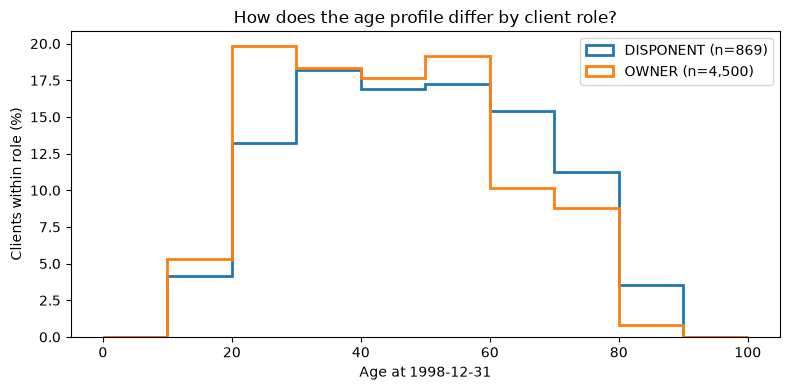

In [36]:
fig, ax = plt.subplots(figsize=(8, 4))
for role, group in clients.groupby('role'):
    ax.hist(group['age'], bins=range(0, 101, 10),
            weights=[100 / len(group)] * len(group),
            histtype='step', linewidth=2, label=f'{role} (n={len(group):,})')
ax.set(title='How does the age profile differ by client role?',
       xlabel=f'Age at {observation_end.date()}', ylabel='Clients within role (%)')
ax.legend()
fig.tight_layout()
plt.show()

### 3.2 Account Opening Cohorts and Statement Frequency

How much of the activity trend could reflect portfolio expansion? Opening cohorts measure acquisition into this sample, not the bank's total acquisition. Statement frequency is a service setting and should not be interpreted as transaction frequency.

frequency,AFTER_TRANSACTION,MONTHLY,WEEKLY
opening_year,,,
1993,21,1056,62
1994,13,399,27
1995,14,614,33
1996,28,1267,68
1997,17,831,50


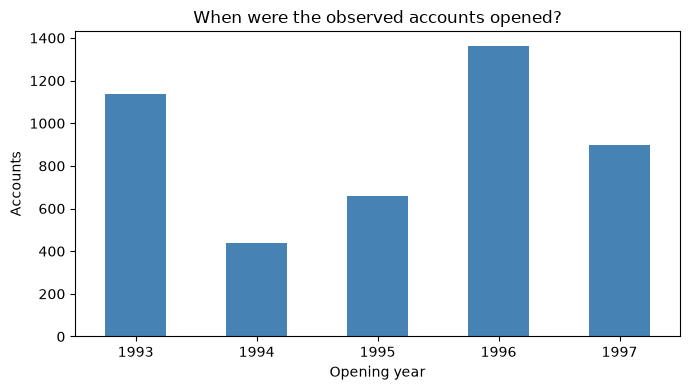

In [37]:
query = '''
SELECT EXTRACT(YEAR FROM date)::int AS opening_year,frequency,COUNT(*) AS accounts
FROM account GROUP BY 1,2 ORDER BY 1,2;
'''

account_cohorts = pd.read_sql(query, engine)

display(account_cohorts.pivot(index='opening_year', columns='frequency', values='accounts').fillna(0).astype(int))
account_cohorts.groupby('opening_year')['accounts'].sum().plot.bar(
    figsize=(7, 4), color='steelblue', title='When were the observed accounts opened?')
plt.xlabel('Opening year')
plt.ylabel('Accounts')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Key Findings

Decoded dates pass the stated validity checks. OWNER ages range from 16 to 80 at 1998-12-31; median ages are 42 for women and 45 for men. DISPONENT ages span 11–87, so they should not be treated as interchangeable with borrowers. The age chart normalizes within each role because the two populations differ substantially in size.

Residence and branch districts differ for 494 of 5,369 clients (9.20%), confirming that the two geographic concepts should remain separate. The largest opening cohort is 1996 with 1,363 accounts (30.29%). Different account vintages create different lifetime opportunities to transact and acquire products.

## 4. Cards and Standing Orders

### 4.1 Card Issuance and Holder Roles

Who holds cards, and how long after opening are they issued? Card records indicate issuance, not current validity, utilization limits, or revolving debt. Role-level penetration uses all dispositions in the relevant role as its denominator.

In [38]:
query = '''
SELECT c.type AS card_type,d.type AS holder_role,COUNT(*) AS cards,
 COUNT(DISTINCT d.account_id) AS accounts,
 PERCENTILE_CONT(0.5) WITHIN GROUP(ORDER BY c.issued-a.date) AS median_days_after_opening,
 MIN(c.issued) AS first_issued,MAX(c.issued) AS last_issued
FROM card c JOIN disp d USING(disp_id) JOIN account a USING(account_id)
GROUP BY 1,2 ORDER BY 1,2;
'''

card_profile = pd.read_sql(query, engine)

card_profile

,card_type,holder_role,cards,accounts,median_days_after_opening,first_issued,last_issued
0,classic,OWNER,659,659,632.0,1993-11-07,1998-12-29
1,gold,OWNER,88,88,1045.0,1995-02-08,1998-12-26
2,junior,OWNER,145,145,633.0,1994-04-05,1998-12-23


In [39]:
query = '''
SELECT d.type AS role,COUNT(*) AS dispositions,
 COUNT(*) FILTER (WHERE EXISTS(SELECT 1 FROM card c WHERE c.disp_id=d.disp_id)) AS cardholders,
 ROUND(100.0*COUNT(*) FILTER (WHERE EXISTS(SELECT 1 FROM card c WHERE c.disp_id=d.disp_id))/COUNT(*),2) AS cardholder_pct
FROM disp d GROUP BY 1 ORDER BY 1;
'''

card_penetration = pd.read_sql(query, engine)

card_penetration

,role,dispositions,cardholders,cardholder_pct
0,DISPONENT,869,0,0.00
1,OWNER,4500,892,19.82


In [40]:
query = '''
WITH first_card AS (
 SELECT d.account_id,MIN(c.issued) AS first_issued FROM card c JOIN disp d USING(disp_id) GROUP BY 1
), withdrawals AS (
 SELECT account_id,COUNT(*) AS withdrawals,MIN(date) AS first_withdrawal
 FROM bank_transaction WHERE operation='CARD_WITHDRAWAL' GROUP BY 1
)
SELECT COUNT(*) AS accounts_with_card_withdrawals,
 COUNT(*) FILTER(WHERE f.account_id IS NULL) AS without_card_record,
 COUNT(*) FILTER(WHERE w.first_withdrawal<f.first_issued) AS first_withdrawal_before_card_issue,
 (SELECT COUNT(*) FROM first_card f WHERE NOT EXISTS(SELECT 1 FROM withdrawals w WHERE w.account_id=f.account_id)) AS card_accounts_without_recorded_card_withdrawal
FROM withdrawals w LEFT JOIN first_card f USING(account_id);
'''

card_timing = pd.read_sql(query, engine)

card_timing

,accounts_with_card_withdrawals,without_card_record,first_withdrawal_before_card_issue,card_accounts_without_recorded_card_withdrawal
0,807,0,0,85


### 4.2 Standing-Order Purposes and Scheduled Amounts

Which recurring payment instructions dominate? Order amounts describe instructions, not executed cash flows. The table has no start/end dates or frequency field, so order totals are not labeled monthly spending and are not added to transactions. Unspecified purpose remains explicitly unclassified.

In [41]:
query = '''
SELECT COALESCE(k_symbol,'UNSPECIFIED') AS purpose,COUNT(*) AS orders,
 COUNT(DISTINCT account_id) AS accounts,SUM(amount) AS total_instruction_amount,
 PERCENTILE_CONT(0.5) WITHIN GROUP(ORDER BY amount) AS median_instruction_amount
FROM standing_order GROUP BY 1 ORDER BY total_instruction_amount DESC;
'''

order_profile = pd.read_sql(query, engine)

order_profile

,purpose,orders,accounts,total_instruction_amount,median_instruction_amount
0,HOUSEHOLD_PAYMENT,3502,3365,13965417.0,3189.5
1,LOAN_PAYMENT,717,717,3035184.5,3990.8
2,UNSPECIFIED,1379,1198,2781938.0,1339.0
3,LEASING_PAYMENT,341,341,759527.1,1951.3
4,INSURANCE_PAYMENT,532,532,686927.0,629.0


In [42]:
query = '''
SELECT l.status,COUNT(*) AS loans,
 COUNT(*) FILTER(WHERE EXISTS(SELECT 1 FROM standing_order s WHERE s.account_id=l.account_id AND s.k_symbol='LOAN_PAYMENT')) AS with_loan_order,
 COUNT(*) FILTER(WHERE EXISTS(SELECT 1 FROM standing_order s WHERE s.account_id=l.account_id AND s.k_symbol='LOAN_PAYMENT' AND ABS(s.amount-l.payments)<=0.01)) AS with_matching_payment_order
FROM loan l GROUP BY l.status ORDER BY l.status;
'''

loan_order_alignment = pd.read_sql(query, engine)

loan_order_alignment

,status,loans,with_loan_order,with_matching_payment_order
0,A,203,203,108
1,B,31,31,9
2,C,403,403,225
3,D,45,45,17


#### Key Findings

All 892 cards are attached to OWNER dispositions: 659 classic, 145 junior, and 88 gold. Cardholder penetration is 19.82% of owners. Gold cards have a longer median delay from opening to issue (1,045 days versus 632 for classic), a descriptive tenure difference rather than evidence of an upgrade path. There are 807 accounts with card withdrawals, none missing a card record or first withdrawing before issuance; 85 card accounts have no recorded card withdrawal. This does not prove non-use for other purposes.

Standing orders cover 3,758 accounts (83.51%). Household payments dominate with 3,502 orders. All 682 loan accounts have a loan-payment order, but only 359 (52.64%) have an amount matching the contractual payment within 0.01. An unmatched instruction is not proof of arrears. The 717 accounts with loan-payment orders exceed the 682 recorded borrowers, so this purpose code is not a reliable substitute for membership in the loan table.

## 5. Transaction Behavior and Monetary Activity

### 5.1 Transaction Mix, Amounts, and Concentration

Which operations explain activity by count and value? Amounts below remain in source monetary units: the local guide does not explicitly specify currency. `CREDIT` is treated as inflow and `DEBIT`/`WITHDRAWAL` as outflow, following the ETL mapping. The additional `WITHDRAWAL` type is documented by the ETL and appears with `CASH_WITHDRAWAL`; it is included once. Net recorded flow is not income, profitability, or an exact balance reconciliation.

In [43]:
query = '''
SELECT type,COALESCE(operation,'INTEREST / NO OPERATION') AS operation,
 COUNT(*) AS transactions,COUNT(DISTINCT account_id) AS accounts,
 SUM(amount) AS total_amount,
 PERCENTILE_CONT(0.5) WITHIN GROUP(ORDER BY amount) AS median_amount,
 PERCENTILE_CONT(0.95) WITHIN GROUP(ORDER BY amount) AS p95_amount
FROM bank_transaction GROUP BY 1,2 ORDER BY total_amount DESC;
'''

transaction_mix = pd.read_sql(query, engine)

transaction_mix

,type,operation,transactions,accounts,total_amount,median_amount,p95_amount
0,CREDIT,CASH_DEPOSIT,156743,4500,2.418522e+09,13564.0,40621.0
1,DEBIT,CASH_WITHDRAWAL,418252,4500,2.130909e+09,1440.0,22800.0
2,CREDIT,TRANSFER_IN,65226,1606,7.814800e+08,5550.0,44749.0
3,DEBIT,TRANSFER_OUT,208283,3602,6.726378e+08,2536.0,8713.0
4,WITHDRAWAL,CASH_WITHDRAWAL,16666,1144,2.086038e+08,12103.0,23449.0
5,CREDIT,INTEREST / NO OPERATION,183114,4453,2.747069e+07,133.0,309.0
6,DEBIT,CARD_WITHDRAWAL,8036,807,1.817040e+07,2200.0,3900.0


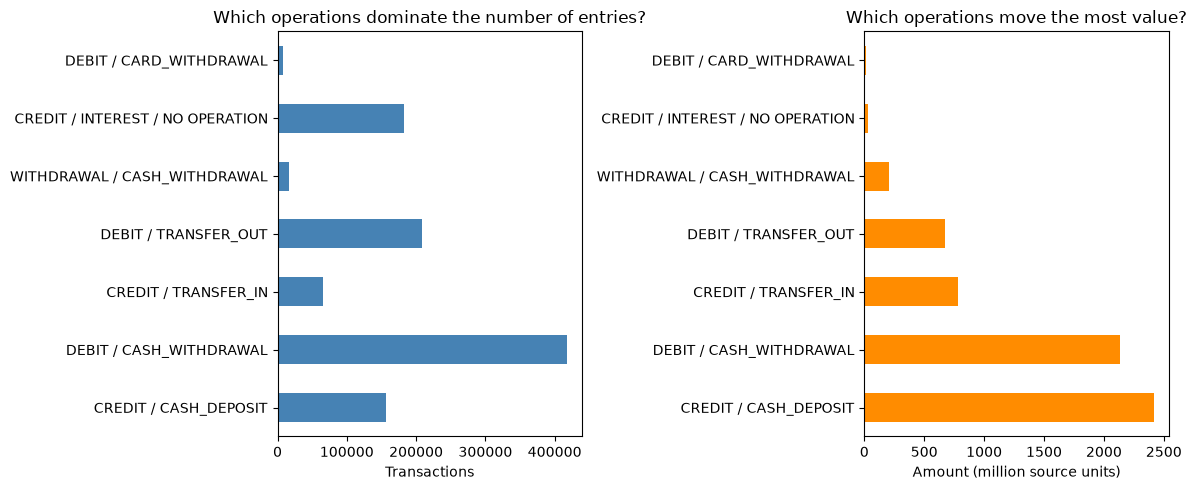

In [44]:
mix_plot = transaction_mix.copy()
mix_plot['label'] = mix_plot['type'] + ' / ' + mix_plot['operation']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
mix_plot.set_index('label')['transactions'].plot.barh(ax=axes[0], color='steelblue')
mix_plot.set_index('label')['total_amount'].div(1e6).plot.barh(ax=axes[1], color='darkorange')
axes[0].set(title='Which operations dominate the number of entries?', xlabel='Transactions', ylabel='')
axes[1].set(title='Which operations move the most value?', xlabel='Amount (million source units)', ylabel='')
fig.tight_layout()
plt.show()

In [45]:
query = '''
SELECT COALESCE(k_symbol,'UNSPECIFIED') AS purpose,COUNT(*) AS transactions,
 COUNT(DISTINCT account_id) AS accounts,SUM(amount) AS amount
FROM bank_transaction GROUP BY 1 ORDER BY amount DESC;
'''

transaction_purposes = pd.read_sql(query, engine)

transaction_purposes

,purpose,transactions,accounts,amount
0,UNSPECIFIED,535314,4500,5.482193e+09
1,HOUSEHOLD_PAYMENT,118065,3297,4.985064e+08
2,PENSION,30338,740,1.674721e+08
3,LOAN_PAYMENT,13580,682,5.525230e+07
4,INTEREST_CREDITED,183114,4453,2.747069e+07
5,INSURANCE_PAYMENT,18500,510,2.417519e+07
6,STATEMENT_PAYMENT,155832,4396,2.686418e+06
7,PENALTY_INTEREST,1577,264,3.766330e+04


In [46]:
query = '''
SELECT a.account_id,a.date AS opened,
 COUNT(t.trans_id) AS transactions,COUNT(DISTINCT DATE_TRUNC('month',t.date)) AS active_months,
 MIN(t.date) AS first_transaction,MAX(t.date) AS last_transaction,
 COALESCE(SUM(t.amount) FILTER(WHERE t.type='CREDIT'),0) AS inflow,
 COALESCE(SUM(t.amount) FILTER(WHERE t.type IN ('DEBIT','WITHDRAWAL')),0) AS outflow,
 AVG(t.balance) AS mean_recorded_balance,MIN(t.balance) AS min_recorded_balance,
 COUNT(t.trans_id) FILTER(WHERE t.balance<0) AS negative_balance_records,
 COUNT(t.trans_id) FILTER(WHERE t.k_symbol='PENALTY_INTEREST') AS penalty_records
FROM account a LEFT JOIN bank_transaction t USING(account_id)
GROUP BY a.account_id,a.date ORDER BY a.account_id;
'''

account_activity = pd.read_sql(query, engine)

account_activity['gross_flow'] = account_activity['inflow'] + account_activity['outflow']
account_activity['net_recorded_flow'] = account_activity['inflow'] - account_activity['outflow']
account_activity['transactions_per_active_month'] = (
    account_activity['transactions'] / account_activity['active_months'].replace(0, float('nan'))
)
display(account_activity[['transactions', 'active_months', 'transactions_per_active_month',
                          'inflow', 'outflow', 'net_recorded_flow', 'mean_recorded_balance']]
        .describe(percentiles=[.25, .5, .75, .95, .99]).round(2))
top_n = max(1, int(len(account_activity) * .1))
top_decile_flow_share = (
    100 * account_activity.nlargest(top_n, 'gross_flow')['gross_flow'].sum()
    / account_activity['gross_flow'].sum()
)
print(f'Top {top_n:,} accounts share of gross recorded flow: {top_decile_flow_share:.2f}%')

,transactions,active_months,transactions_per_active_month,inflow,outflow,net_recorded_flow,mean_recorded_balance
count,4500.00,4500.00,4500.00,4500.00,4500.00,4500.00,4500.00
mean,234.74,41.12,5.56,717216.09,673404.70,43811.40,36667.86
std,126.85,18.15,1.34,670245.70,658588.98,25439.45,15165.63
min,9.00,9.00,1.00,19700.00,1400.00,-25821.00,5711.30
25%,133.00,26.00,4.77,228050.58,199079.65,23075.10,23570.88
50%,208.00,36.00,5.44,466683.35,425676.75,38494.85,34696.54
75%,330.00,61.00,6.28,1005418.65,946921.85,60589.40,47818.69
95%,459.00,70.00,7.95,2138764.36,2067633.49,92962.70,64392.22
99%,565.01,72.00,8.96,3034652.56,2973442.18,108432.55,72904.42
max,675.00,72.00,11.47,3857257.40,3761845.00,138317.80,81192.76


Top 450 accounts share of gross recorded flow: 32.11%


### 5.2 Negative Balances and Penalty Interest

How widespread are overdraft observations? A transaction-weighted average balance is not a daily average balance. Dates have no intraday timestamp, and transaction identifiers do not guarantee event order; no reconstructed daily closing balance or duration in overdraft is asserted.

In [47]:
overdraft_profile = account_activity.assign(
    negative_balance_observed=account_activity['negative_balance_records'].gt(0),
    penalty_interest_observed=account_activity['penalty_records'].gt(0)
).groupby(['negative_balance_observed', 'penalty_interest_observed']).agg(
    accounts=('account_id', 'size'),
    median_minimum_balance=('min_recorded_balance', 'median'),
    median_transactions=('transactions', 'median')
)
overdraft_profile

accounts  \
negative_balance_observed penalty_interest_observed             
False                     False                          4203   
                          True                              9   
True                      False                            33   
                          True                            255   

                                                     median_minimum_balance  \
negative_balance_observed penalty_interest_observed                           
False                     False                                       700.0   
                          True                                        413.3   
True                      False                                     -2352.4   
                          True                                      -2344.9   

                                                     median_transactions  
negative_balance_observed penalty_interest_observed                       
False                     False                                    206.0  
                          True                                     393.0  
True                      False                                    189.0  
                          True                                     267.0

#### Key Findings

Cash deposits account for 2,418.52 million source units, the largest operation-level value. DEBIT cash withdrawals account for 418,252 entries, the largest operation/type count. The top 450 accounts generate 32.11% of gross recorded flow; pooled totals therefore give disproportionate weight to more active and longer-observed accounts.

Unspecified purposes cover 535,314 transactions, so total credits cannot be relabeled as salary. Recorded pension transactions occur on 740 accounts and provide an observed engagement category without establishing total income.

Negative-balance and penalty signals overlap but are not identical: 255 accounts have both, 33 have negative balances without penalties, and nine have penalties without a recorded negative balance. This supports retaining the two observations separately; incomplete balance timing prevents an exact overdraft-duration claim.

## 6. Temporal Behavior and Observation Exposure

### 6.1 Monthly Activity and Flows

Does portfolio growth explain increasing transaction counts? Monthly totals are paired with activity per account transacting in that month. An active account means at least one recorded transaction, not an independently observed open/closed status. Credit, debit, and net flow include internal fees and interest; they do not identify salary or disposable income.

,month,transactions,active_accounts,inflow,outflow,negative_balance_accounts,transactions_per_active_account,negative_balance_account_pct,net_flow
0,1993-01-01,177,96,667457.6,34700.0,0,1.843750,0.000000,632757.6
71,1998-12-01,23553,4424,95155975.9,76541117.8,53,5.323915,1.198011,18614858.1


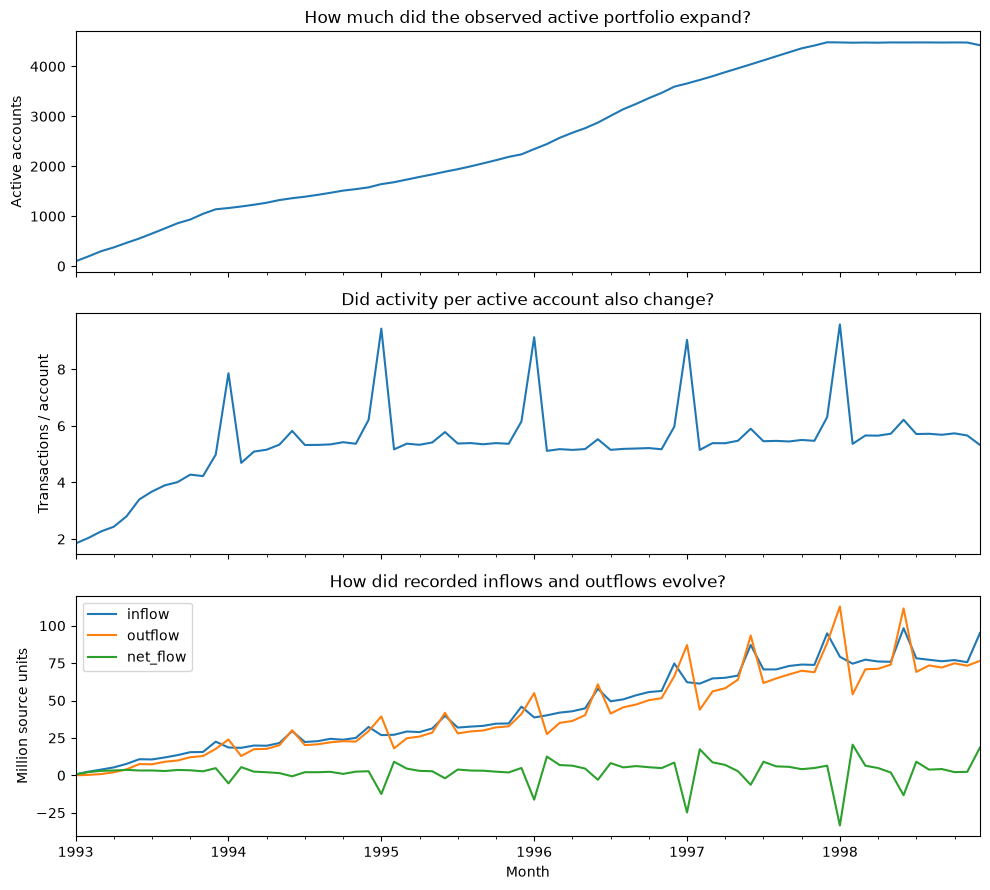

In [48]:
query = '''
SELECT DATE_TRUNC('month',date)::date AS month,
 COUNT(*) AS transactions,COUNT(DISTINCT account_id) AS active_accounts,
 SUM(amount) FILTER(WHERE type='CREDIT') AS inflow,
 SUM(amount) FILTER(WHERE type IN ('DEBIT','WITHDRAWAL')) AS outflow,
 COUNT(DISTINCT account_id) FILTER(WHERE balance<0) AS negative_balance_accounts
FROM bank_transaction GROUP BY 1 ORDER BY 1;
'''

monthly_activity = pd.read_sql(query, engine)

monthly_activity['month'] = pd.to_datetime(monthly_activity['month'])
monthly_activity['transactions_per_active_account'] = monthly_activity['transactions'] / monthly_activity['active_accounts']
monthly_activity['negative_balance_account_pct'] = 100 * monthly_activity['negative_balance_accounts'] / monthly_activity['active_accounts']
monthly_activity['net_flow'] = monthly_activity['inflow'] - monthly_activity['outflow']
display(monthly_activity.iloc[[0, -1]])
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
monthly_activity.plot(x='month', y='active_accounts', ax=axes[0], legend=False)
axes[0].set(title='How much did the observed active portfolio expand?', ylabel='Active accounts')
monthly_activity.plot(x='month', y='transactions_per_active_account', ax=axes[1], legend=False)
axes[1].set(title='Did activity per active account also change?', ylabel='Transactions / account')
monthly_activity.set_index('month')[['inflow', 'outflow', 'net_flow']].div(1e6).plot(ax=axes[2])
axes[2].set(title='How did recorded inflows and outflows evolve?', ylabel='Million source units', xlabel='Month')
fig.tight_layout()
plt.show()

### 6.2 Recent Activity and Within-Year Variation

Which accounts were still transacting near the observation end? Lack of recent transactions is a descriptive signal, not confirmed churn. Compare months within the latest full calendar year to reduce the acquisition/exposure distortion in pooled seasonality. A single year does not establish a recurring seasonal effect.

In [49]:
account_activity['days_since_last_transaction'] = (
    observation_end - pd.to_datetime(account_activity['last_transaction'])
).dt.days
recency_summary = pd.Series({
    'accounts': len(account_activity),
    'no_transaction_in_last_90_days': account_activity['days_since_last_transaction'].gt(90).sum(),
    'no_transaction_in_last_180_days': account_activity['days_since_last_transaction'].gt(180).sum(),
    'median_days_since_last_transaction': account_activity['days_since_last_transaction'].median()
})
display(recency_summary)
full_years = monthly_activity.groupby(monthly_activity['month'].dt.year).size()
latest_full_year = int(full_years[full_years.eq(12)].index.max())
within_year_activity = monthly_activity.loc[monthly_activity['month'].dt.year.eq(latest_full_year),
    ['month', 'active_accounts', 'transactions_per_active_account', 'negative_balance_account_pct']]
display(within_year_activity.round({column: 2 for column in within_year_activity.select_dtypes('number').columns}))

accounts                              4500.0
no_transaction_in_last_90_days          16.0
no_transaction_in_last_180_days         14.0
median_days_since_last_transaction       0.0
dtype: float64

,month,active_accounts,transactions_per_active_account,negative_balance_account_pct
60,1998-01-01,4480,9.58,1.43
61,1998-02-01,4475,5.36,0.67
62,1998-03-01,4478,5.66,0.92
63,1998-04-01,4475,5.65,0.76
64,1998-05-01,4480,5.72,1.00
65,1998-06-01,4479,6.21,1.14
66,1998-07-01,4480,5.71,1.09
67,1998-08-01,4480,5.72,1.09
68,1998-09-01,4478,5.68,1.14
69,1998-10-01,4480,5.73,1.12


In [50]:
query = '''
SELECT EXTRACT(MONTH FROM date)::int AS month, type,
 COUNT(*) AS transactions
FROM bank_transaction
WHERE date >= (SELECT DATE_TRUNC('year', MAX(date)) FROM bank_transaction)
GROUP BY 1,2 ORDER BY 1,2;
'''

latest_year_type_mix = pd.read_sql(query, engine)

display(latest_year_type_mix.pivot(index='month', columns='type', values='transactions').fillna(0).astype(int))

type,CREDIT,DEBIT,WITHDRAWAL
month,,,
1,10172,32414,354
2,10040,13620,335
3,10005,14836,500
4,9864,14979,454
5,9817,15350,467
6,10005,17369,459
7,10074,15012,496
8,9948,15187,487
9,9875,15106,469


#### Key Findings

The active portfolio expands from 96 accounts in January 1993 to 4,424 in December 1998. Transactions per active account also rise from 1.84 to 5.32, so raw volume growth is not solely a count of newly represented accounts.

Within 1998, January records 9.58 transactions per active account, versus 5.32–6.21 in the remaining months. The type breakdown shows 32,414 DEBIT entries in January versus 13,620 in February, while CREDIT entries are similar (10,172 versus 10,040). This locates the peak in debit entries; it does not establish the underlying business cause or justify deleting them.

Only 16 accounts have their last transaction more than 90 days before the observation end, and 14 more than 180 days before it. These are recency observations, not confirmed churn labels.

## 7. Loans and Credit Risk

### 7.1 Contract Status, Size, and Term

What is the observed performance of the loan book? The source guide defines:

| Status | Meaning | Interpretation |
|---|---|---|
| A | Finished, no problems | Completed performing contract |
| B | Finished, not paid | Completed adverse contract |
| C | Running, OK so far | Ongoing; final outcome unobserved |
| D | Running, client in debt | Ongoing adverse status |

`B + D` is called **observed adverse status**, not a realized default probability. Completed-contract and ongoing-contract proportions are reported separately. Loan amount is original principal, not outstanding exposure, loss, or EAD. This is descriptive portfolio analysis, not underwriting advice or a fitted risk model.

In [51]:
query = '''
SELECT l.loan_id,l.account_id,l.date AS granted,l.amount,l.duration,l.payments,l.status,
 a.date AS account_opened, d.client_id AS owner_client_id,c.district_id AS residence_district_id,
 r.region,r.average_salary,r.unemployment_rate_96
FROM loan l JOIN account a USING(account_id)
JOIN disp d ON d.account_id=l.account_id AND d.type='OWNER'
JOIN client c USING(client_id) JOIN district r ON r.district_id=c.district_id
ORDER BY l.loan_id;
'''

loans = pd.read_sql(query, engine)

loans['adverse_status'] = loans['status'].isin(['B', 'D'])
loans['contract_group'] = loans['status'].map({'A': 'Completed', 'B': 'Completed', 'C': 'Running', 'D': 'Running'})
loans['grant_year'] = pd.to_datetime(loans['granted']).dt.year
loans['account_age_days_at_grant'] = (
    pd.to_datetime(loans['granted']) - pd.to_datetime(loans['account_opened'])
).dt.days
loan_status_summary = loans.groupby('status').agg(
    loans=('loan_id', 'size'), original_principal=('amount', 'sum'),
    median_amount=('amount', 'median'), median_duration=('duration', 'median'),
    median_payment=('payments', 'median')
)
loan_status_summary['loan_share_pct'] = 100 * loan_status_summary['loans'] / len(loans)
contract_risk_summary = loans.groupby('contract_group').agg(
    loans=('loan_id', 'size'), adverse=('adverse_status', 'sum'),
    adverse_pct=('adverse_status', lambda x: 100 * x.mean())
)
display(loan_status_summary.round(2))
display(contract_risk_summary.round(2))
display(loans[['amount', 'duration', 'payments', 'account_age_days_at_grant']].describe().round(2))

,loans,original_principal,median_amount,median_duration,median_payment,loan_share_pct
status,,,,,,
A,203,18603216.0,79632.0,24.0,3874.0,29.77
B,31,4362348.0,96396.0,24.0,5746.0,4.55
C,403,69078372.0,153504.0,48.0,3698.0,59.09
D,45,11217804.0,260400.0,48.0,5120.0,6.60


,loans,adverse,adverse_pct
contract_group,,,
Completed,234,31,13.25
Running,448,45,10.04


,amount,duration,payments,account_age_days_at_grant
count,682.00,682.00,682.00,682.00
mean,151410.18,36.49,4190.66,398.24
std,113372.41,17.08,2215.83,164.61
min,4980.00,12.00,304.00,102.00
25%,66732.00,24.00,2477.00,261.25
50%,116928.00,36.00,3934.00,395.50
75%,210654.00,48.00,5813.50,528.75
max,590820.00,60.00,9910.00,697.00


### 7.2 Term, Vintage, and Uncertainty

Do adverse proportions differ across contract terms or origination years? Always show denominators and completed/running composition. Wilson 95% intervals describe binomial sampling uncertainty; they do not correct for selection, censoring, or differing follow-up. Small cells support hypotheses rather than a ranked risk policy.

loans  adverse  adverse_pct  lower_95_pct  \
duration contract_group                                              
12       Completed         103       10         9.71          5.36   
         Running            28        1         3.57          0.63   
24       Completed          75       11        14.67          8.39   
         Running            63        6         9.52          4.44   
36       Completed          39        7        17.95          8.98   
         Running            91        8         8.79          4.52   
48       Completed          13        2        15.38          4.33   
         Running           125       14        11.20          6.79   
60       Completed           4        1        25.00          4.56   
         Running           141       16        11.35          7.11   

                         upper_95_pct  
duration contract_group                
12       Completed              16.96  
         Running                17.71  
24       Completed              24.38  
         Running                19.26  
36       Completed              32.67  
         Running                16.40  
48       Completed              42.24  
         Running                17.92  
60       Completed              69.94  
         Running                17.64

loans  adverse  adverse_pct  lower_95_pct  \
grant_year contract_group                                              
1993       Completed          20        4        20.00          8.07   
1994       Completed          85       12        14.12          8.26   
           Running            16        2        12.50          3.50   
1995       Completed          51        6        11.76          5.50   
           Running            39        6        15.38          7.25   
1996       Completed          35        6        17.14          8.10   
           Running            82       10        12.20          6.76   
1997       Completed          43        3         6.98          2.40   
           Running           153       23        15.03         10.23   
1998       Running           158        4         2.53          0.99   

                           upper_95_pct  
grant_year contract_group                
1993       Completed              41.60  
1994       Completed              23.07  
           Running                36.02  
1995       Completed              23.38  
           Running                29.73  
1996       Completed              32.68  
           Running                21.01  
1997       Completed              18.61  
           Running                21.55  
1998       Running                 6.33

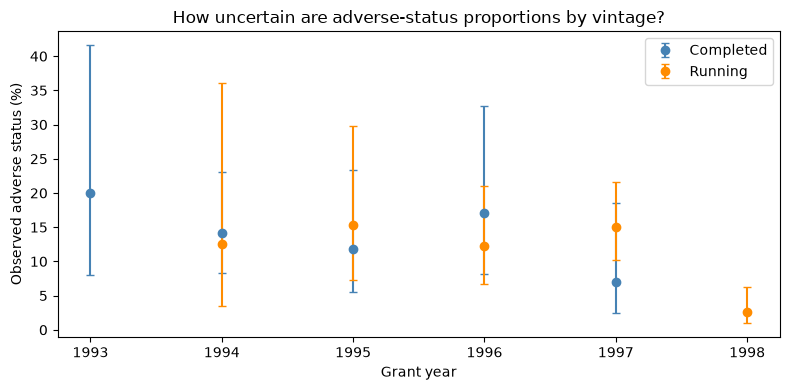

In [52]:
import numpy as np


def add_rate_interval(summary):
    summary = summary.copy()
    n = summary['loans']
    p = summary['adverse'] / n
    z = 1.96
    center = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    margin = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    summary['adverse_pct'] = 100 * p
    summary['lower_95_pct'] = 100 * (center - margin)
    summary['upper_95_pct'] = 100 * (center + margin)
    return summary


loan_term_risk = add_rate_interval(loans.groupby(['duration', 'contract_group']).agg(
    loans=('loan_id', 'size'), adverse=('adverse_status', 'sum')
))
loan_vintage_risk = add_rate_interval(loans.groupby(['grant_year', 'contract_group']).agg(
    loans=('loan_id', 'size'), adverse=('adverse_status', 'sum')
))
display(loan_term_risk.round(2))
display(loan_vintage_risk.round(2))
fig, ax = plt.subplots(figsize=(8, 4))
for group, color in [('Completed', 'steelblue'), ('Running', 'darkorange')]:
    subset = loan_vintage_risk.xs(group, level='contract_group')
    ax.errorbar(subset.index, subset['adverse_pct'],
                yerr=[subset['adverse_pct'] - subset['lower_95_pct'],
                      subset['upper_95_pct'] - subset['adverse_pct']],
                fmt='o', capsize=3, color=color, label=group)
ax.set(title='How uncertain are adverse-status proportions by vintage?',
       xlabel='Grant year', ylabel='Observed adverse status (%)')
ax.legend()
fig.tight_layout()
plt.show()

### 7.3 Pre-Loan Behavior and Subsequent Observed Status

Are cash-flow and balance signals already different before origination? This descriptive comparison aggregates only transactions in the 180 calendar days strictly before each grant date, excluding the grant day because intraday order is unavailable. It does not build a modeling table or use post-grant activity as a predictor. Observation days and record counts are shown because accounts have different histories. No transaction means missing behavior, not zero risk.

In [53]:
query = '''
SELECT l.loan_id,l.status,l.date-a.date AS account_age_days_at_grant,
 LEAST(180,l.date-a.date) AS possible_pregrant_days,
 COUNT(t.trans_id) AS pregrant_transactions,
 COUNT(DISTINCT t.date) AS transaction_days,
 AVG(t.balance) AS mean_recorded_balance,
 MIN(t.balance) AS minimum_recorded_balance,
 SUM(t.amount) FILTER(WHERE t.type='CREDIT') AS inflow,
 SUM(t.amount) FILTER(WHERE t.type IN ('DEBIT','WITHDRAWAL')) AS outflow,
 CASE WHEN COUNT(t.trans_id)>0 THEN BOOL_OR(t.balance<0) END AS negative_balance_observed,
 CASE WHEN COUNT(t.trans_id)>0 THEN BOOL_OR(COALESCE(t.k_symbol='PENALTY_INTEREST',FALSE)) END AS penalty_observed
FROM loan l JOIN account a USING(account_id)
LEFT JOIN bank_transaction t ON t.account_id=l.account_id
 AND t.date>=l.date-180 AND t.date<l.date
GROUP BY l.loan_id,l.status,l.date,a.date ORDER BY l.loan_id;
'''

preloan_behavior = pd.read_sql(query, engine)

preloan_summary = preloan_behavior.groupby('status').agg(
    loans=('loan_id', 'size'),
    with_history=('pregrant_transactions', lambda x: x.gt(0).sum()),
    median_possible_days=('possible_pregrant_days', 'median'),
    median_transaction_days=('transaction_days', 'median'),
    median_transactions=('pregrant_transactions', 'median'),
    median_recorded_balance=('mean_recorded_balance', 'median'),
    median_inflow=('inflow', 'median'), median_outflow=('outflow', 'median'),
    negative_balance_loans=('negative_balance_observed', 'sum'),
    negative_balance_pct=('negative_balance_observed', lambda x: 100 * x.dropna().mean()),
    penalty_loans=('penalty_observed', 'sum'),
    penalty_pct=('penalty_observed', lambda x: 100 * x.dropna().mean())
)
display(preloan_summary.round(2))

,loans,with_history,median_possible_days,median_transaction_days,median_transactions,median_recorded_balance,median_inflow,median_outflow,negative_balance_loans,negative_balance_pct,penalty_loans,penalty_pct
status,,,,,,,,,,,,
A,203,203,180.0,31.0,41.0,44010.44,147755.1,149844.6,0,0.00,1,0.49
B,31,31,180.0,24.0,34.0,34798.28,117757.1,120772.4,4,12.90,5,16.13
C,403,403,180.0,31.0,40.0,43022.83,144339.8,140369.0,0,0.00,2,0.50
D,45,45,180.0,29.0,40.0,30097.68,135079.1,156106.1,15,33.33,16,35.56


#### Key Findings

The 682 loans comprise 203 A, 31 B, 403 C, and 45 D contracts. Observed adverse status affects 76 loans (11.14%). Among completed contracts, 31 of 234 are B (13.25%); among running contracts, 45 of 448 are D (10.04%). Their denominators and outcome maturity differ, so neither proportion should be presented as a directly comparable lifetime default rate.

Median payments are higher in B than A (5,746 versus 3,874), and D than C (5,120 versus 3,698). This is a contract-level association, not an affordability measure because personal income is unavailable. The apparent 2.53% adverse proportion for 1998 originations concerns 158 running loans; short follow-up can explain part of its contrast with older vintages. Long-term completed groups are small: only four completed 60-month loans are observed, yielding a very wide interval.

All 682 loans have transactions in the pre-grant window. Negative balances were recorded before grant for 4/31 B loans (12.90%) and 15/45 D loans (33.33%), versus none of the A/C loans. Penalty observations occurred for 1/203 A, 5/31 B, 2/403 C, and 16/45 D loans. Pre-grant transaction-weighted balance medians are also lower for B/D. These are retrospective associations worth testing later with a defined target and time-based validation; they are not demonstrated predictive performance.

## 8. Geographic and Socioeconomic Context

### 8.1 Residential Representation and Branch Reach

Where do clients live, and where are accounts held? Residential customer counts and branch-account counts are kept separate. Customers per 1,000 residents is sample representation, not market share: the population is broader than the eligible customer base and no bank-wide sampling frame is provided.

In [54]:
query = '''
WITH customers AS (
 SELECT district_id,COUNT(*) AS clients FROM client GROUP BY 1
), branches AS (
 SELECT district_id,COUNT(*) AS accounts FROM account GROUP BY 1
), credit AS (
 SELECT c.district_id,COUNT(*) AS loans,
 COUNT(*) FILTER(WHERE l.status IN ('B','D')) AS adverse,
 SUM(l.amount) AS original_principal
 FROM loan l JOIN disp d ON d.account_id=l.account_id AND d.type='OWNER'
 JOIN client c USING(client_id) GROUP BY 1
)
SELECT r.district_id,r.district_name,r.region,r.inhabitants,r.urban_ratio,
 r.average_salary,r.unemployment_rate_95,r.unemployment_rate_96,
 r.entrepreneurs_per_1000,r.crimes_95,r.crimes_96,
 COALESCE(c.clients,0) AS clients,COALESCE(b.accounts,0) AS branch_accounts,
 COALESCE(l.loans,0) AS loans,COALESCE(l.adverse,0) AS adverse,
 COALESCE(l.original_principal,0) AS original_principal
FROM district r LEFT JOIN customers c USING(district_id)
LEFT JOIN branches b USING(district_id) LEFT JOIN credit l USING(district_id)
ORDER BY r.district_id;
'''

district_profile = pd.read_sql(query, engine)

district_profile['clients_per_1000_residents'] = 1000 * district_profile['clients'] / district_profile['inhabitants']
district_profile['crimes_96_per_1000'] = 1000 * district_profile['crimes_96'] / district_profile['inhabitants']
region_profile = district_profile.groupby('region').agg(
    clients=('clients', 'sum'), branch_accounts=('branch_accounts', 'sum'),
    inhabitants=('inhabitants', 'sum'), loans=('loans', 'sum'), adverse=('adverse', 'sum')
)
region_profile['clients_per_1000_residents'] = 1000 * region_profile['clients'] / region_profile['inhabitants']
region_profile = add_rate_interval(region_profile)
display(region_profile.round(2))
display(district_profile.nlargest(10, 'clients')[['district_name', 'region', 'clients',
    'branch_accounts', 'clients_per_1000_residents', 'loans', 'adverse']].round(2))

,clients,branch_accounts,inhabitants,loans,adverse,clients_per_1000_residents,adverse_pct,lower_95_pct,upper_95_pct
region,,,,,,,,,
Prague,663,554,1204953,79,6,0.55,7.59,3.53,15.60
central Bohemia,664,574,1105234,87,10,0.60,11.49,6.36,19.88
east Bohemia,660,544,1234781,87,8,0.53,9.20,4.73,17.11
north Bohemia,561,457,1178977,62,1,0.48,1.61,0.29,8.59
north Moravia,920,793,1970302,117,19,0.47,16.24,10.65,23.98
south Bohemia,449,370,700595,61,9,0.64,14.75,7.96,25.72
south Moravia,937,778,2054989,133,15,0.46,11.28,6.95,17.78
west Bohemia,515,430,859306,56,8,0.60,14.29,7.42,25.74


,district_name,region,clients,branch_accounts,clients_per_1000_residents,loans,adverse
0,Hl.m. Praha,Prague,663,554,0.55,79,6
73,Ostrava - mesto,north Moravia,180,135,0.56,20,3
69,Karvina,north Moravia,169,152,0.59,25,3
53,Brno - mesto,south Moravia,155,128,0.40,23,5
63,Zlin,south Moravia,109,92,0.55,16,1
71,Olomouc,north Moravia,104,88,0.46,15,3
67,Frydek - Mistek,north Moravia,86,83,0.38,15,1
45,Nachod,east Bohemia,76,59,0.67,8,0
51,Usti nad Orlici,east Bohemia,73,57,0.53,15,1
4,Kolin,central Bohemia,71,65,0.74,11,1


### 8.2 Socioeconomic Context and Observed Loan Status

Do district conditions differ across observed contract statuses? District salary is an area average, not personal income; unemployment, urbanization, entrepreneurship, and crime are contextual measures. The 1995/1996 indicators may postdate early loan grants, so they must not be treated as historically available underwriting inputs. Associations are ecological and do not establish individual creditworthiness or causation.

,average_salary,unemployment_rate_96,urban_ratio,entrepreneurs_per_1000,crimes_96_per_1000
status,,,,,
A,8994.0,3.49,61.9,115.0,31.79
B,9045.0,3.74,62.6,118.0,31.96
C,8965.0,3.47,62.1,116.0,31.71
D,8746.0,3.64,61.9,110.0,29.03


,average_salary,unemployment_rate_96,urban_ratio,entrepreneurs_per_1000,crimes_96_per_1000
count,77.0,77.00,77.0,77.0,77.00
min,8110.0,0.43,33.9,81.0,15.95
median,8814.0,3.60,59.8,113.0,28.50
max,12541.0,9.40,100.0,167.0,82.25


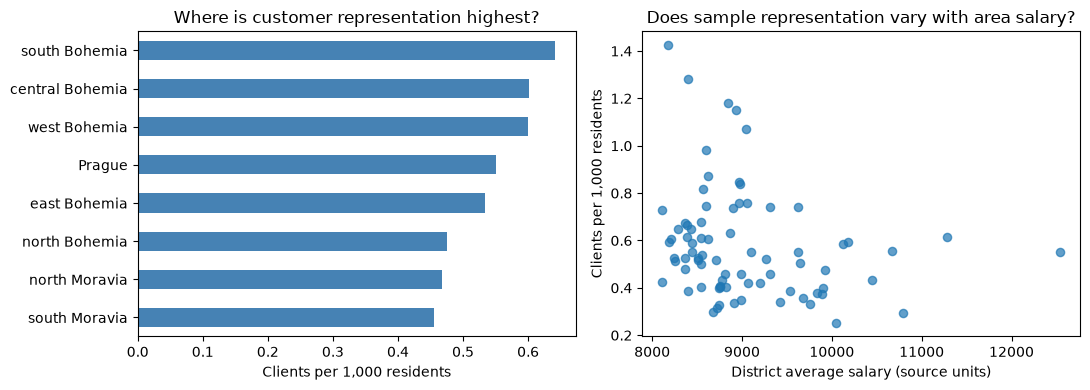

In [55]:
context_columns = ['average_salary', 'unemployment_rate_96', 'urban_ratio',
                   'entrepreneurs_per_1000', 'crimes_96_per_1000']
loan_context = loans[['loan_id', 'status', 'residence_district_id']].merge(
    district_profile[['district_id'] + context_columns],
    left_on='residence_district_id', right_on='district_id', validate='many_to_one'
)
display(loan_context.groupby('status')[context_columns].median().round(2))
display(district_profile[context_columns].agg(['count', 'min', 'median', 'max']).round(2))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
region_profile['clients_per_1000_residents'].sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set(title='Where is customer representation highest?', xlabel='Clients per 1,000 residents', ylabel='')
axes[1].scatter(district_profile['average_salary'], district_profile['clients_per_1000_residents'],
                s=35, alpha=.7)
axes[1].set(title='Does sample representation vary with area salary?',
            xlabel='District average salary (source units)', ylabel='Clients per 1,000 residents')
fig.tight_layout()
plt.show()

#### Key Findings

South Moravia has the most resident clients (937), but south Bohemia has the highest representation relative to population (0.64 clients per 1,000 residents). North Moravia has the most branch accounts (793). Rankings depend on whether the question concerns residence, branch activity, or population-adjusted representation.

Observed adverse loan proportions range from 1/62 in north Bohemia (1.61%) to 19/117 in north Moravia (16.24%). Small counts, uncertainty intervals, contract maturity, and customer selection limit interpretation; the regional table is not a credit policy ranking. The salary scatter shows substantial variation in sample representation and does not establish a simple causal salary effect. Area indicators remain context, not inferred personal attributes.

## 9. Cross-Product Relationships and Customer Intelligence

### 9.1 Product Combinations at Account Level

Which observed relationships distinguish accounts? Each product is aggregated independently to one row per account. Product presence means observed in this extract, not simultaneous adoption or current holdings. Standing orders have no adoption dates. These combinations can suggest questions about service engagement, but do not identify eligible sales leads or unmet demand.

In [56]:
query = '''
WITH cards AS (
 SELECT d.account_id,COUNT(*) AS cards FROM card c JOIN disp d USING(disp_id) GROUP BY 1
), orders AS (
 SELECT account_id,COUNT(*) AS orders FROM standing_order GROUP BY 1
), loans AS (
 SELECT account_id,COUNT(*) AS loans FROM loan GROUP BY 1
)
SELECT a.account_id,a.date AS opened,COALESCE(c.cards,0) AS cards,
 COALESCE(o.orders,0) AS orders,COALESCE(l.loans,0) AS loans
FROM account a LEFT JOIN cards c USING(account_id)
LEFT JOIN orders o USING(account_id) LEFT JOIN loans l USING(account_id)
ORDER BY a.account_id;
'''

account_products = pd.read_sql(query, engine)

account_products['has_card'] = account_products['cards'].gt(0)
account_products['has_order'] = account_products['orders'].gt(0)
account_products['has_loan'] = account_products['loans'].gt(0)
product_combinations = account_products.groupby(['has_card', 'has_order', 'has_loan']).agg(
    accounts=('account_id', 'size')
)
product_combinations['account_pct'] = 100 * product_combinations['accounts'] / len(account_products)
display(product_combinations.round(2))
product_activity = account_products.merge(
    account_activity[['account_id', 'transactions_per_active_month', 'mean_recorded_balance']],
    on='account_id', validate='one_to_one'
)
product_activity_summary = product_activity.groupby(['has_card', 'has_loan']).agg(
    accounts=('account_id', 'size'),
    median_transactions_per_active_month=('transactions_per_active_month', 'median'),
    median_recorded_balance=('mean_recorded_balance', 'median')
)
display(product_activity_summary.round(2))

accounts  account_pct
has_card has_order has_loan                       
False    False     False          552        12.27
         True      False         2544        56.53
                   True           512        11.38
True     False     False          190         4.22
         True      False          532        11.82
                   True           170         3.78

accounts  median_transactions_per_active_month  \
has_card has_loan                                                   
False    False         3096                                  5.20   
         True           512                                  6.64   
True     False          722                                  5.59   
         True           170                                  6.75   

                   median_recorded_balance  
has_card has_loan                           
False    False                    28640.53  
         True                     40696.72  
True     False                    50544.18  
         True                     55125.04

### 9.2 Owner Demographics and Product Reach

How does observed product reach vary with owner age? Restricting attribution to OWNER avoids duplicating account products across authorized users. Age bands are descriptive display groups, not engineered model inputs. Differences can reflect cohort, tenure, eligibility, or selection rather than an effect of age itself.

,owners,card_pct,order_pct,loan_pct
age_band,,,,
Under 30,1131,25.02,71.79,15.30
30–44,1201,20.65,83.76,19.82
45–59,1281,23.97,84.15,18.58
60+,887,6.09,97.18,3.72


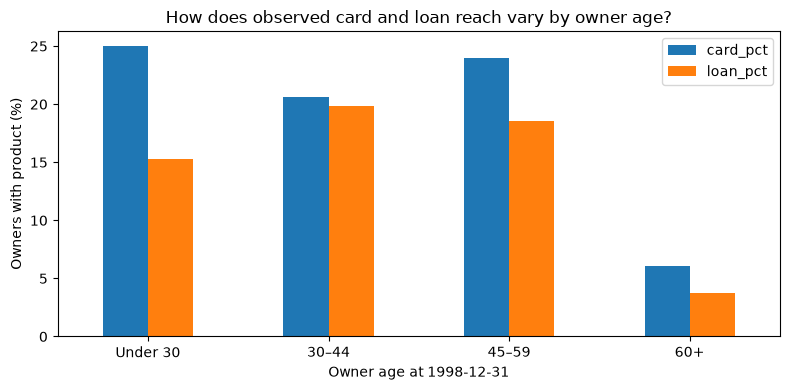

In [57]:
owner_products = clients.loc[clients['role'].eq('OWNER'),
    ['client_id', 'account_id', 'age', 'gender']].merge(
        account_products, on='account_id', validate='one_to_one'
)
owner_products['age_band'] = pd.cut(owner_products['age'],
    bins=[0, 30, 45, 60, float('inf')], right=False, labels=['Under 30', '30–44', '45–59', '60+'])
owner_product_reach = owner_products.groupby('age_band', observed=True).agg(
    owners=('client_id', 'size'),
    card_pct=('has_card', lambda x: 100 * x.mean()),
    order_pct=('has_order', lambda x: 100 * x.mean()),
    loan_pct=('has_loan', lambda x: 100 * x.mean())
)
display(owner_product_reach.round(2))
owner_product_reach[['card_pct', 'loan_pct']].plot.bar(
    figsize=(8, 4), title='How does observed card and loan reach vary by owner age?')
plt.ylabel('Owners with product (%)')
plt.xlabel(f'Owner age at {observation_end.date()}')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Key Findings

The largest combination is standing orders without cards or recorded loans: 2,544 accounts (56.53%). Another 552 (12.27%) have none of these three additional products, while 170 (3.78%) have all three. Card presence among loan accounts is 170/682 (24.93%). These are observed combinations, not simultaneous holdings or evidence of unmet demand.

Median transactions per active month are 5.20 for accounts without cards or loans and 6.75 for accounts with both. Product breadth and activity are associated, but the comparison does not isolate tenure or selection effects.

Among 887 owners aged 60+, card reach is 6.09%, loan reach 3.72%, and standing-order reach 97.18%. Among 1,131 owners under 30, the corresponding figures are 25.02%, 15.30%, and 71.79%. This contrast motivates distinct engagement questions rather than an automatic sales or risk decision.

## 10. Key Findings and Analytical Handoff

- **Reliable relational base:** no orphan rows, all accounts have owner and transaction coverage, and the targeted chronological/monetary checks pass. Preserve the source-level exceptions and non-key coincidences documented above.
- **Customer grain matters:** 869 accounts have an additional authorized user. Product and transaction totals must not be repeated for every disposition; residence and branch district also answer different questions.
- **Engagement differs by product and exposure:** standing orders reach 83.51% of accounts, cards 19.82%, and loans 15.16%. Cash dominates transaction value, and 10% of accounts contribute 32.11% of gross recorded flow.
- **Time affects interpretation:** portfolio growth contributes to volume trends; the January 1998 debit peak should remain visible. Recent activity is widespread, and inactivity alone does not establish churn.
- **Credit outcomes require maturity-aware treatment:** the 76 B/D loans represent 11.14% of the observed book, while completed and running adverse proportions are 13.25% and 10.04%, respectively. Pre-grant balance and penalty differences merit subsequent validation without claiming predictive power.
- **Geography and product breadth provide descriptive context:** regional sample representation, owner age, and product combinations vary, but ecological measures, sparse outcomes, and selection prevent causal or individual-level conclusions.

### Scope and Limitations

- Findings describe this historical extract; they are not claims about the entire bank or present-day customers.
- Transaction dates lack intraday order. Balance summaries are transaction-weighted observations, not reconstructed daily balances. No unsupported churn or profitability labels are assigned.
- Ongoing loan contracts are censored; `C` is not a known final good outcome. `B + D` is an observed adverse-status proportion, not PD. Principal is not outstanding exposure or realized loss.
- Geographic attributes describe areas and may not have been available at origination. They are not individual income or causal drivers.
- Card issuance and undated standing-order presence do not prove simultaneous product ownership. Cross-product comparisons are descriptive and may reflect selection and tenure.
- All original records remain intact, including account `9051` interest entries and the missing observed counterparty on `trans_id 236564`.

### Decisions for Subsequent Notebooks

Use account grain for activity and product totals, with explicit OWNER attribution when a customer grain is needed. A later risk notebook must define a target, prediction date, outcome horizon, and eligibility population before creating features; it must enforce information availability at that date and use time-aware evaluation. A later segmentation notebook should distinguish product presence, engagement, and observation exposure before clustering. No feature dataset, segmentation, model, or database mutation is produced here.

### 10.1 Execution and Reconciliation Checks

The following checks reconcile analytical grains and totals against the database overview. They do not delete or alter data. All code cells must also complete without an execution error when this notebook is run from its `notebooks` directory using the project environment.

In [58]:
source_counts = table_counts.set_index('table_name')['row_count']

reconciliation_checks = pd.Series({
    'one_row_per_account_in_activity': account_activity['account_id'].is_unique and len(account_activity) == source_counts['account'],
    'one_row_per_account_in_products': account_products['account_id'].is_unique and len(account_products) == source_counts['account'],
    'one_row_per_owner': owner_products['account_id'].is_unique and len(owner_products) == source_counts['account'],
    'clients_reconcile': clients['client_id'].nunique() == source_counts['client'],
    'monthly_transactions_reconcile': monthly_activity['transactions'].sum() == source_counts['bank_transaction'],
    'account_transactions_reconcile': account_activity['transactions'].sum() == source_counts['bank_transaction'],
    'transaction_mix_reconciles': transaction_mix['transactions'].sum() == source_counts['bank_transaction'],
    'cards_reconcile': account_products['cards'].sum() == source_counts['card'],
    'orders_reconcile': account_products['orders'].sum() == source_counts['standing_order'],
    'loan_grain_reconciles': loans['loan_id'].is_unique and len(loans) == source_counts['loan'],
    'pregrant_grain_reconciles': preloan_behavior['loan_id'].is_unique and len(preloan_behavior) == source_counts['loan'],
    'regional_loans_reconcile': region_profile['loans'].sum() == source_counts['loan'],
    'product_combinations_reconcile': product_combinations['accounts'].sum() == source_counts['account']
}, name='passed')

display(reconciliation_checks.to_frame())
assert reconciliation_checks.all(), 'Review the failed reconciliation before using the EDA.'
print(f'EDA complete: {len(reconciliation_checks)} reconciliation checks passed; no source records modified.')

,passed
one_row_per_account_in_activity,True
one_row_per_account_in_products,True
one_row_per_owner,True
clients_reconcile,True
monthly_transactions_reconcile,True
account_transactions_reconcile,True
transaction_mix_reconciles,True
cards_reconcile,True
orders_reconcile,True
loan_grain_reconciles,True


EDA complete: 13 reconciliation checks passed; no source records modified.
